### LSE Data Analytics Online Career Accelerator 

# DA301:  Advanced Analytics for Organisational Impact

## Assignment template

### Scenario
You are a data analyst working for Turtle Games, a game manufacturer and retailer. They manufacture and sell their own products, along with sourcing and selling products manufactured by other companies. Their product range includes books, board games, video games and toys. They have a global customer base and have a business objective of improving overall sales performance by utilising customer trends. In particular, Turtle Games wants to understand: 
- how customers accumulate loyalty points (Week 1)
- exploring the structure using decision trees (Week 2)
- exploring clusters in customer behaviour (Week 3)
- can social data (e.g. customer reviews) be used in marketing campaigns (Week 4)
- loading, transforming and visualising data in R (Week 5)
- statistical analysis and modelling in R (Week 6)

## 1. Load and explore the data

In [173]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm 
from statsmodels.formula.api import ols

In [174]:
# Load the CSV file(s) as reviews.
reviews = pd.read_csv('/Users/annievert/Desktop/LSE COURSE EVERYTHING/Course 3 /ASSIGNMENT/LSE_DA301_assignment_files_new/turtle_reviews.csv')

# View the DataFrame.
reviews.head()
reviews.info()
reviews.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  2000 non-null   object 
 1   age                     2000 non-null   int64  
 2   remuneration (k£)       2000 non-null   float64
 3   spending_score (1-100)  2000 non-null   int64  
 4   loyalty_points          2000 non-null   int64  
 5   education               2000 non-null   object 
 6   language                2000 non-null   object 
 7   platform                2000 non-null   object 
 8   product                 2000 non-null   int64  
 9   review                  2000 non-null   object 
 10  summary                 2000 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 172.0+ KB


,age,remuneration (k£),spending_score (1-100),loyalty_points,product
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,39.495000,48.079060,50.000000,1578.032000,4320.521500
std,13.573212,23.123984,26.094702,1283.239705,3148.938839
min,17.000000,12.300000,1.000000,25.000000,107.000000
25%,29.000000,30.340000,32.000000,772.000000,1589.250000
50%,38.000000,47.150000,50.000000,1276.000000,3624.000000
75%,49.000000,63.960000,73.000000,1751.250000,6654.000000
max,72.000000,112.340000,99.000000,6847.000000,11086.000000


In [175]:
# Any missing values?
reviews.isnull().sum()

gender                    0
age                       0
remuneration (k£)         0
spending_score (1-100)    0
loyalty_points            0
education                 0
language                  0
platform                  0
product                   0
review                    0
summary                   0
dtype: int64

In [176]:
print(reviews.columns)

Index(['gender', 'age', 'remuneration (k£)', 'spending_score (1-100)',
       'loyalty_points', 'education', 'language', 'platform', 'product',
       'review', 'summary'],
      dtype='object')


## 2. Drop columns

In [177]:
# Drop unnecessary columns.
reviews = reviews.drop(columns=['language', 'platform'])

# View column names.
reviews

,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap
...,...,...,...,...,...,...,...,...,...
1995,Female,37,84.46,69,4031,PhD,977,The perfect word game for mixed ages (with Mom...,The perfect word game for mixed ages (with Mom
1996,Female,43,92.66,8,539,PhD,979,Great game. Did not think I would like it whe...,Super fun
1997,Male,34,92.66,91,5614,graduate,1012,Great game for all.........\nKeeps the mind ni...,Great Game
1998,Male,34,98.40,16,1048,PhD,1031,fun game!,Four Stars


## 3. Rename columns

In [178]:
# Rename the column headers.
# renaming columns 
reviews = reviews.rename(columns={'remuneration (k£)' : 'remuneration',
                                 'spending_score (1-100)' : 'spending_score'})

# View column names.
print(reviews.columns)

Index(['gender', 'age', 'remuneration', 'spending_score', 'loyalty_points',
       'education', 'product', 'review', 'summary'],
      dtype='object')


## 4. Save the DataFrame as a CSV file

In [179]:
# Create a CSV file as output.
# save new df as csv 
reviews.to_csv('reviews_updated', index=False)

In [180]:
# Import new CSV file with Pandas.
reviews_updated = pd.read_csv('reviews_updated')

# View DataFrame.
reviews_updated

,gender,age,remuneration,spending_score,loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap
...,...,...,...,...,...,...,...,...,...
1995,Female,37,84.46,69,4031,PhD,977,The perfect word game for mixed ages (with Mom...,The perfect word game for mixed ages (with Mom
1996,Female,43,92.66,8,539,PhD,979,Great game. Did not think I would like it whe...,Super fun
1997,Male,34,92.66,91,5614,graduate,1012,Great game for all.........\nKeeps the mind ni...,Great Game
1998,Male,34,98.40,16,1048,PhD,1031,fun game!,Four Stars


## 5. Linear regression

### 5a) spending vs loyalty

In [181]:
# Define independent variable.
X_spend = reviews_updated['spending_score'].values.reshape(-1,1)

# Define dependent variable.
y_spend = reviews_updated['loyalty_points'].values.reshape(-1,1)

# Create model and print summary of metrics.
from sklearn.linear_model import LinearRegression 

lm = LinearRegression() 
lm.fit(X_spend,y_spend)

LinearRegression()

In [182]:
# Extract the estimated parameters.
intercept = lm.intercept_
slope = lm.coef_
print(f"Intercept: {intercept}")
print(f"Slope (Coefficient): {slope}")

# Extract the standard errors.
X_spend_const = sm.add_constant(X_spend)
model_sm = sm.OLS(y_spend, X_spend_const).fit()
print(model_sm.summary())

Intercept: [-75.05266293]
Slope (Coefficient): [[33.06169326]]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     1648.
Date:                Mon, 04 May 2026   Prob (F-statistic):          2.92e-263
Time:                        23:59:31   Log-Likelihood:                -16550.
No. Observations:                2000   AIC:                         3.310e+04
Df Residuals:                    1998   BIC:                         3.312e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

R-squared value = 45.2% of the variation in loyalty points is due to spending score.
coefficient = 33.06
pvalue = 0 - highly significant predictor 

In [183]:
# Extract the predicted values.
y_pred = model_sm.predict(X_spend_const)
y_pred

array([1214.35337415, 2602.94449102,  123.31749662, ..., 2933.56142361,
        453.93442921,  189.44088314])

In [184]:
# Set the X coefficient and the constant to generate the regression table.


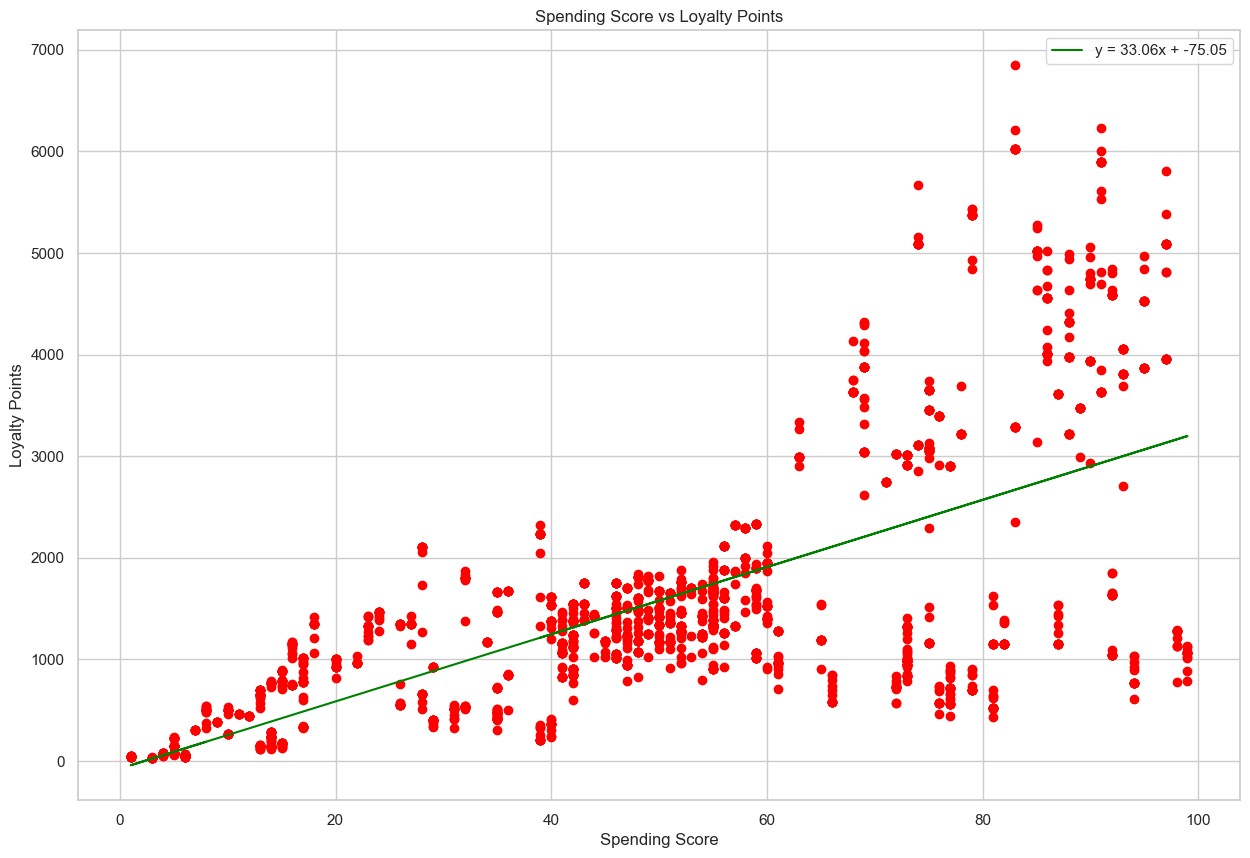

In [185]:
# Plot the graph with a regression line.
plt.scatter(reviews_updated['spending_score'], reviews_updated['loyalty_points'], color='red')
plt.plot(X_spend, y_pred, color='green',
         label=f'y = {slope[0][0]:.2f}x + {intercept[0]:.2f}')
plt.xlabel('Spending Score')
plt.ylabel('Loyalty Points')
plt.title('Spending Score vs Loyalty Points')
plt.legend()

# View the output.
plt.show()

### 5b) renumeration vs loyalty

In [186]:
# Define independent variable.
x_remun = reviews_updated['remuneration'].values.reshape(-1,1)

# Define dependent variable.
y_remun = reviews_updated['loyalty_points'].values.reshape(-1,1)

# Create model and print summary of metrics.
lm = LinearRegression() 
lm.fit(x_remun,y_remun)

LinearRegression()

In [187]:
# Extract the estimated parameters.
intercept = lm.intercept_
slope = lm.coef_
print(f"Intercept: {intercept}")
print(f"Slope (Coefficient): {slope}")

# Extract the standard errors.
x_remun_const = sm.add_constant(x_remun)
model_sm = sm.OLS(y_remun, x_remun_const).fit()
print(model_sm.summary())

# Extract the predicted values.
y_pred_remun = model_sm.predict(x_remun_const)
y_pred_remun

Intercept: [-65.6865128]
Slope (Coefficient): [[34.18782549]]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.380
Model:                            OLS   Adj. R-squared:                  0.379
Method:                 Least Squares   F-statistic:                     1222.
Date:                Mon, 04 May 2026   Prob (F-statistic):          2.43e-209
Time:                        23:59:31   Log-Likelihood:                -16674.
No. Observations:                2000   AIC:                         3.335e+04
Df Residuals:                    1998   BIC:                         3.336e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

array([ 354.82374068,  354.82374068,  382.85775758, ..., 3102.15739671,
       3298.39551499, 3102.15739671])

r-squared = 38%
coef = 34.19
p-value = 0 - highly significant 

In [188]:
# Set the the X coefficient and the constant to generate the regression table.


# View the output.


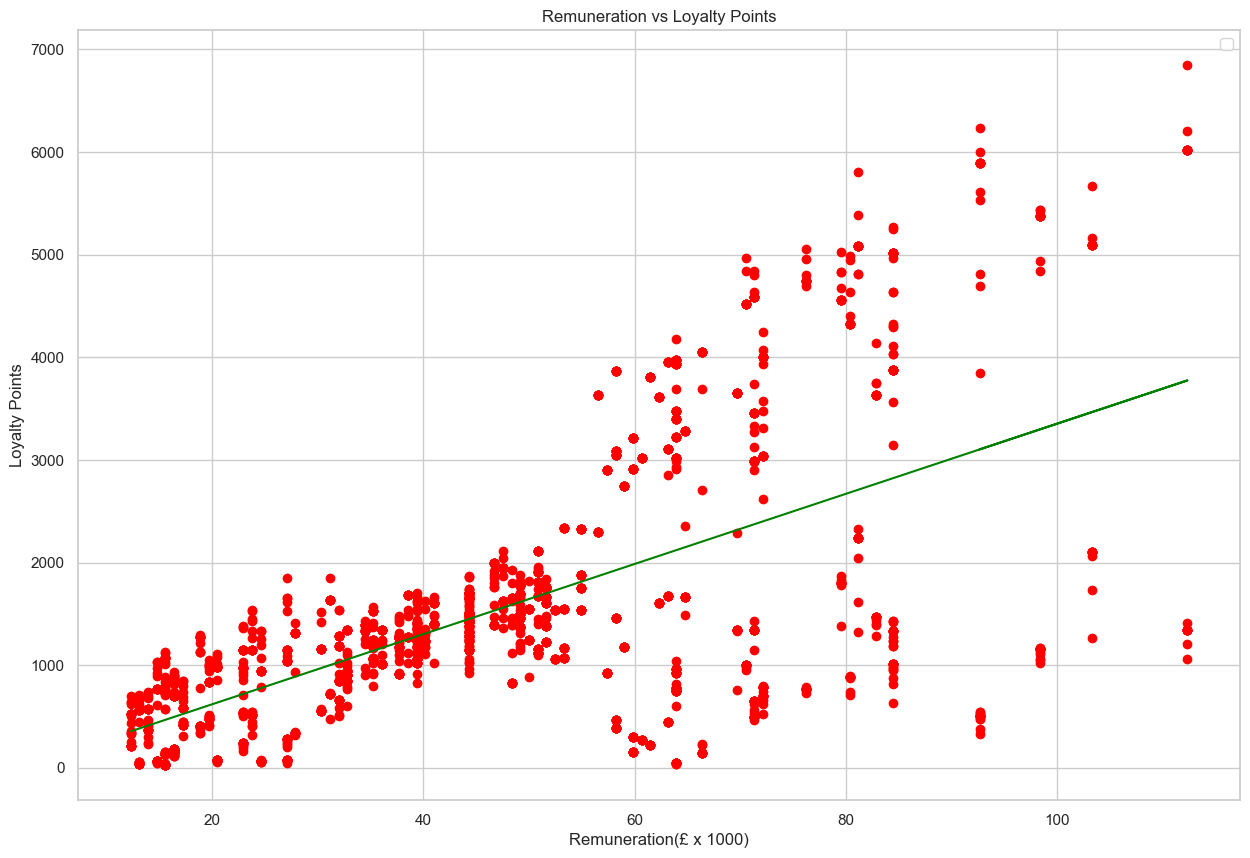

In [189]:
# Plot graph with regression line.
# Plot the graph with a regression line.
plt.scatter(reviews_updated['remuneration'], reviews_updated['loyalty_points'], color='red')
plt.plot(x_remun, y_pred_remun, color='green')
plt.xlabel('Remuneration(£ x 1000)')
plt.ylabel('Loyalty Points')
plt.title('Remuneration vs Loyalty Points')
plt.legend()

# View the output.
plt.show()

### 5c) age vs loyalty

In [190]:
# Define independent variable.
x_age = reviews_updated['age'].values.reshape(-1,1)

# Define dependent variable.
y_age = reviews_updated['loyalty_points'].values.reshape(-1,1)

# Create model and print summary of metrics.
lm = LinearRegression() 
lm.fit(x_age,y_age)

LinearRegression()

In [191]:
# Extract the estimated parameters.
intercept = lm.intercept_
slope = lm.coef_
print(f"Intercept: {intercept}")
print(f"Slope (Coefficient): {slope}")

# Extract the standard errors.
x_age_const = sm.add_constant(x_age)
model_sm_age = sm.OLS(y_age, x_age_const).fit()
print(model_sm_age.summary())

# Extract the predicted values.
y_pred_age = model_sm_age.predict(x_age_const)
y_pred_age

Intercept: [1736.5177394]
Slope (Coefficient): [[-4.01280515]]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3.606
Date:                Mon, 04 May 2026   Prob (F-statistic):             0.0577
Time:                        23:59:32   Log-Likelihood:                -17150.
No. Observations:                2000   AIC:                         3.430e+04
Df Residuals:                    1998   BIC:                         3.431e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

array([1664.2872467 , 1644.22322095, 1648.2360261 , ..., 1600.0823643 ,
       1600.0823643 , 1608.1079746 ])

R_squared = 2% 
coef = -4.01
Pvalue = 0.058 - this is higher than 0.05
std error = 2.11

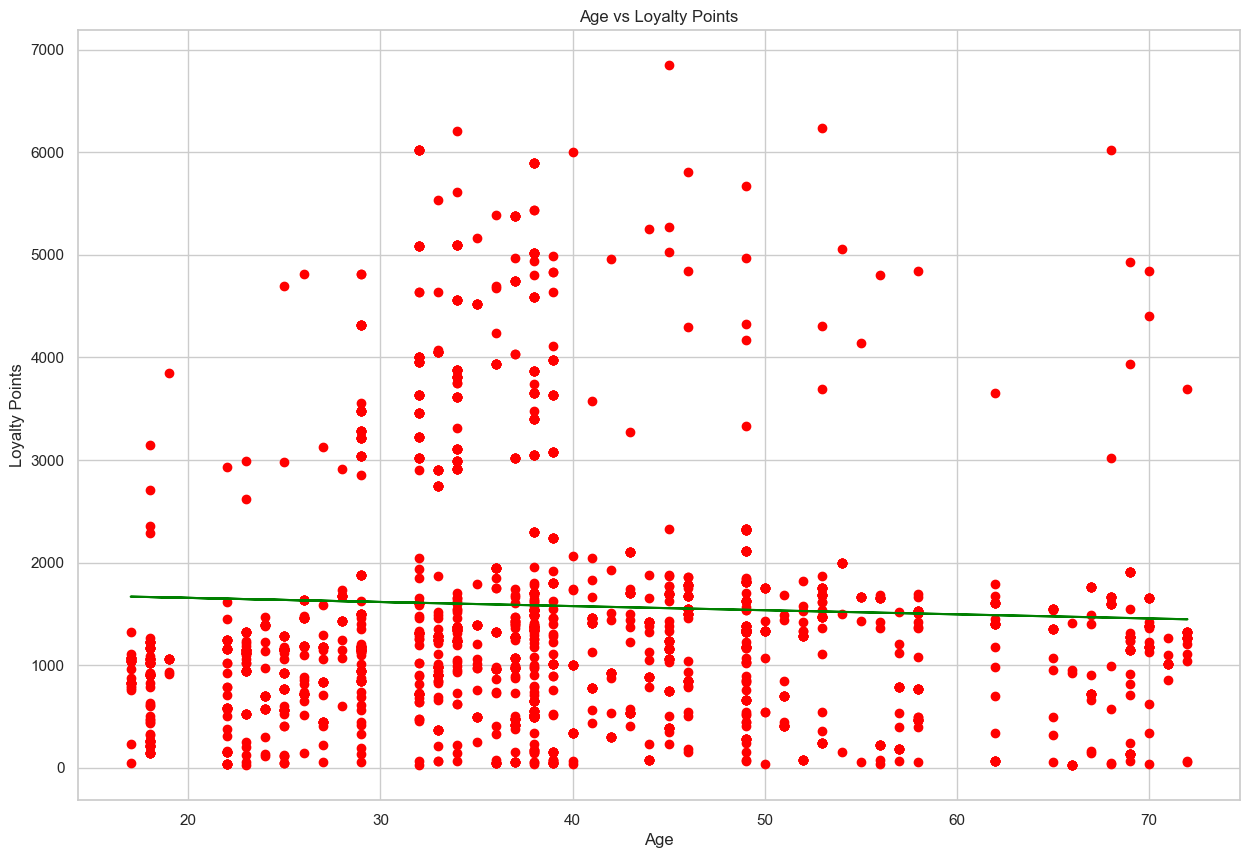

In [192]:
# Plot the graph with a regression line.
plt.scatter(reviews_updated['age'], reviews_updated['loyalty_points'], color='red')
plt.plot(x_age, y_pred_age, color='green')
plt.xlabel('Age')
plt.ylabel('Loyalty Points')
plt.title('Age vs Loyalty Points')

# View the output.
plt.show()

In [193]:
reviews_updated['age'] = reviews['age'].values
reviews_updated

,gender,age,remuneration,spending_score,loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap
...,...,...,...,...,...,...,...,...,...
1995,Female,37,84.46,69,4031,PhD,977,The perfect word game for mixed ages (with Mom...,The perfect word game for mixed ages (with Mom
1996,Female,43,92.66,8,539,PhD,979,Great game. Did not think I would like it whe...,Super fun
1997,Male,34,92.66,91,5614,graduate,1012,Great game for all.........\nKeeps the mind ni...,Great Game
1998,Male,34,98.40,16,1048,PhD,1031,fun game!,Four Stars


Average Spending Score by Age Group:
        age  spending_score
0  Under 25       52.354839
1     25-35       62.328302
2     35-45       45.991525
3     45-55       42.531034
4       55+       40.239286


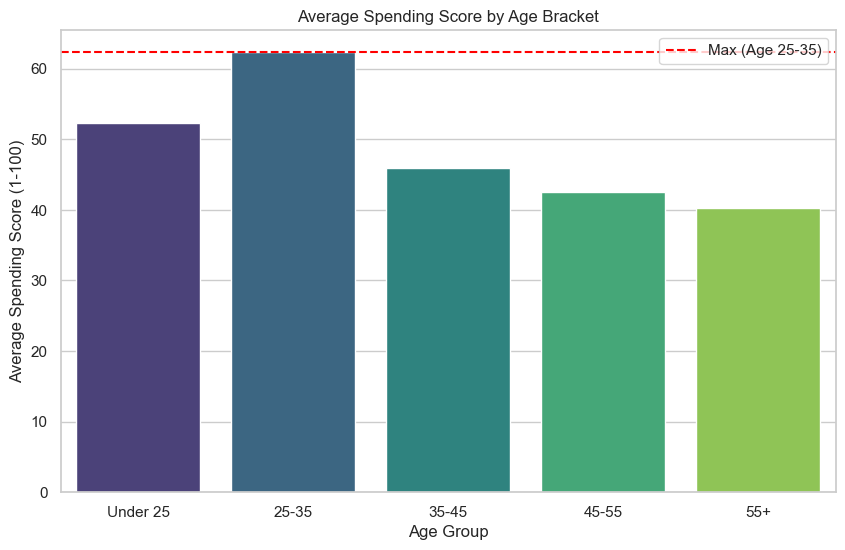

In [194]:
# determining spending score per age group 

# setting age brakcets
bins = [0, 25, 35, 45, 55, 100]
labels = ['Under 25', '25-35', '35-45', '45-55', '55+']

# Use pd.cut to segment the 'age' column into groups
reviews_updated_2 = reviews_updated.copy() 

reviews_updated_2['age'] = pd.cut(reviews_updated_2['age'], bins=bins, labels=labels)

# determine the mean spending score for each group
age_analysis = reviews_updated_2.groupby('age', observed=True)['spending_score'].mean().reset_index()

# view results
print("Average Spending Score by Age Group:")
print(age_analysis)

# Visualise with a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=age_analysis, x='age', y='spending_score', palette='viridis')

# Add a horizontal line at the 62.3 mark to highlight the max
plt.axhline(62.3, color='red', linestyle='--', label='Max (Age 25-35)')

plt.title('Average Spending Score by Age Bracket')
plt.xlabel('Age Group')
plt.ylabel('Average Spending Score (1-100)')
plt.legend()
plt.show()

## 6. Observations and insights

***Your observations here...***






our findings tell us that both spending score and remuneration are indicators of number of loyalty points, however age is not a significant indicator of ones loyalty points as the R-squared value is only 2% which is extremely weak. There is also no clear trend in the regression line. The Pvalue is also over 0.05 which meabs we must reject H0 ( age is a key indicator of Loyalty points).

## 1. Load and prepare the data

In [195]:
# Import all the necessary packages
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import statsmodels.api as sm
import warnings
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn import tree
import matplotlib.pyplot as plt

# Settings for the notebook.
warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = [15, 10]

In [196]:
# Create your new DataFrame.
reviews_2 = pd.DataFrame(reviews_updated)
reviews_2.head()

,gender,age,remuneration,spending_score,loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


In [197]:
# Moving independent variable to separate dataframe
cols = ['remuneration', 'age', 'spending_score']

# Specify Y
y = reviews_2['loyalty_points']

# Specify X
X = reviews_2[cols]

In [198]:
# Review X and Y.
print(y)
print(X)

0        210
1        524
2         40
3        562
4        366
        ... 
1995    4031
1996     539
1997    5614
1998    1048
1999     479
Name: loyalty_points, Length: 2000, dtype: int64
      remuneration  age  spending_score
0            12.30   18              39
1            12.30   23              81
2            13.12   22               6
3            13.12   25              77
4            13.94   33              40
...            ...  ...             ...
1995         84.46   37              69
1996         92.66   43               8
1997         92.66   34              91
1998         98.40   34              16
1999         92.66   32               8

[2000 rows x 3 columns]


## 2. Create train and test data sets.

In [199]:
# Split the data into test and train data.
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=42)

## 3. Create Decision tree regressor

In [200]:
# Create your decision tree regressor.
from sklearn.tree import DecisionTreeRegressor  

X_train_encoded = pd.get_dummies(X_train, drop_first=True)

# create dec tree regressor class 
dtree = DecisionTreeRegressor(max_depth=3, min_samples_leaf=10, random_state=42)

dtree.fit(X_train_encoded, y_train)

DecisionTreeRegressor(max_depth=3, min_samples_leaf=10, random_state=42)

In [201]:
# Evaluate the model.
from sklearn import metrics
import math

# Predict using the test data
y_pred = dtree.predict(X_test)
y_pred = y_pred.astype(y_test.dtype) 
y_pred

array([ 155, 3504, 3504, 1455, 1455, 1455,  155, 1198, 1455, 3504, 1455,
       1455, 1455, 1455,  643, 1455, 1455,  155,  678,  155, 1455,  678,
       1455, 1455, 1455, 1455, 4849, 1455,  643, 1198,  678,  155,  643,
       1455, 1455, 1455, 1455, 1455, 1455, 1455, 1455, 1455, 1455, 4849,
       4849,  155, 1455, 1455, 1455, 1455,  643,  678,  678,  155, 1455,
       1198,  678, 4849,  643, 3504, 1455, 1455, 1455, 1455, 1455,  678,
       4849,  155, 1455, 1455, 1455, 4849, 4849, 1455, 3504, 1455, 1455,
       4849, 1455,  678, 1455, 1455, 1455,  643, 1455, 1455,  678, 1455,
       1455, 1198, 4849, 1198,  155, 1455,  155,  155, 1455, 1198, 1455,
       1455, 1455, 4849, 1198,  643, 1198, 1455,  678, 1455,  730,  155,
       3504, 1455, 1198, 1198, 3504,  643, 1455, 3504, 1455, 1455,  155,
        678, 1455, 1455, 4849, 3504, 1455, 1455, 4849, 1455, 1198,  730,
        155, 3504,  155, 1198,  678,  678,  643, 3504, 1455, 1455,  678,
       1455, 4849,  155, 1455, 1455, 1198, 1455, 14

In [202]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared Score: {r2:.2f}")

Mean Absolute Error: 267.07
Root Mean Squared Error: 371.42
R-squared Score: 0.91


- 91% of the variation in loyalty points can be explained by the variables you used (Remuneration, Age, and Spending Score)
- On average, the model’s predictions are off by about 267 points
- because this number (371) is higher than the MAE (267), it tells us that the model has a few outliers

# Prune the model.
model = DecisionTreeRegressor(criterion = 'gini',
                             max_depth = 5,
                             min_samples_leaf = 5,
                             min_samples_split = 5)
model.fit(X_train,y_train)
y_predicted=model.predict(X_test)
accuracy_score(y_test,y_predicted)

## 4. Fit and plot final model.

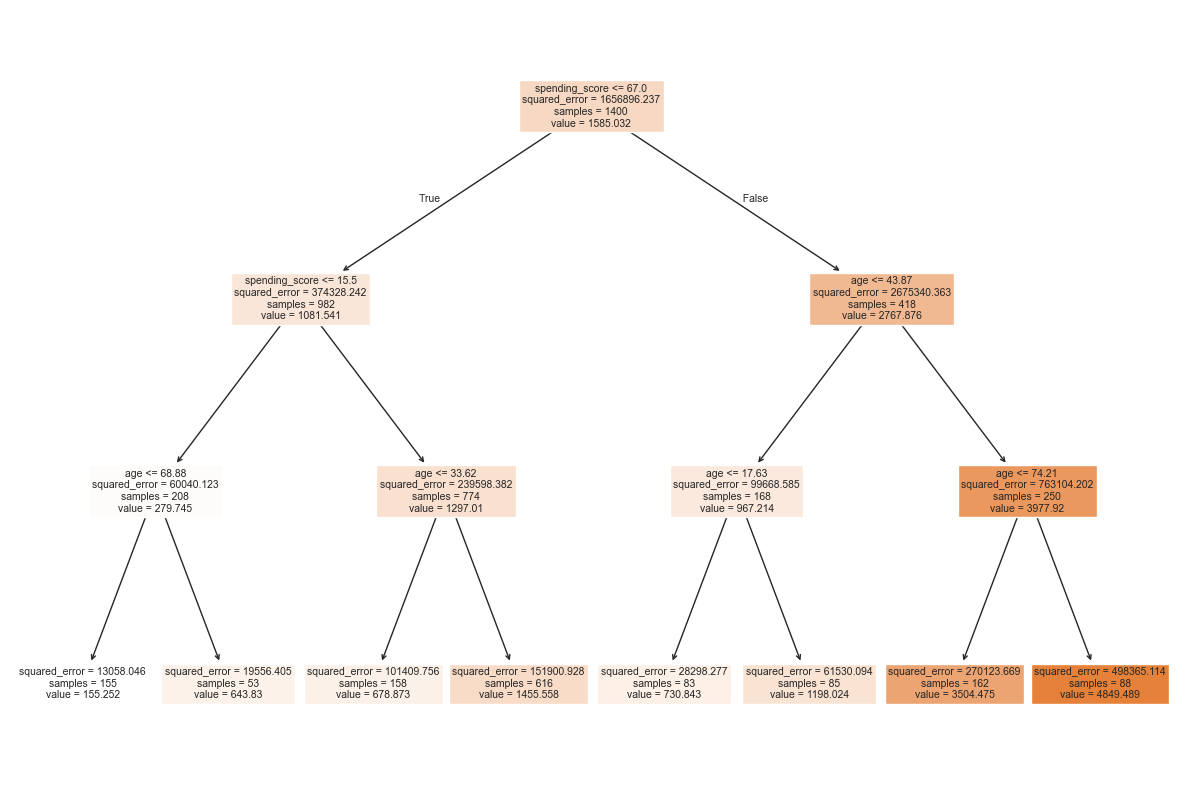

In [203]:
# Fit and plot final model.
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
tree.plot_tree(dtree, 
               feature_names=['age', 'remuneration', 'spending_score'], 
               filled=True)
plt.show()

In [204]:
dtree.feature_importances_

array([0.52484974, 0.        , 0.47515026])

## 5. Discuss: Insights and observations

***Your observations here...***

# Interpret model and note observations.
- The most important feature for predicting loyalty_points appears to be spending_score. If a person's score is <=67, they go to the left.If it's >67, they go to the right.
- the right side is much darker orange, meaning those branches lead to much higher predicted loyalty values (3504 and 4849).
- samples are evenly distributed
- remuneratoin doesnt appear, meaning age and spending score are much better predictors of loyalty than how much money the person makes.

# 

# Week 3 assignment: Clustering with *k*-means using Python

The marketing department also wants to better understand the usefulness of renumeration and spending scores but do not know where to begin. You are tasked to identify groups within the customer base that can be used to target specific market segments. Use *k*-means clustering to identify the optimal number of clusters and then apply and plot the data using the created segments.

## Instructions
1. Prepare the data for clustering. 
    1. Import the CSV file you have prepared in Week 1.
    2. Create a new DataFrame (e.g. `df3`) containing the `renumeration` and `spending_score` columns.
    3. Explore the new DataFrame. 
2. Plot the renumeration versus spending score.
    1. Create a scatterplot.
    2. Create a pairplot.
3. Use the Silhouette and Elbow methods to determine the optimal number of clusters for *k*-means clustering.
    1. Plot both methods and explain how you determine the number of clusters to use.
    2. Add titles and legends to the plot.
4. Evaluate the usefulness of at least three values for *k* based on insights from the Elbow and Silhoutte methods.
    1. Plot the predicted *k*-means.
    2. Explain which value might give you the best clustering.
5. Fit a final model using your selected value for *k*.
    1. Justify your selection and comment on the respective cluster sizes of your final solution.
    2. Check the number of observations per predicted class.
6. Plot the clusters and interpret the model.

## 1. Load and explore the data

In [205]:
# Import necessary libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist

import warnings
warnings.filterwarnings('ignore')

In [206]:
# Load the CSV file(s) as df3.
# Create your new DataFrame.
df3 = pd.DataFrame(reviews_updated)

# View DataFrame.
df3.head()

,gender,age,remuneration,spending_score,loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


## 2. Plot

<Axes: xlabel='remuneration', ylabel='spending_score'>

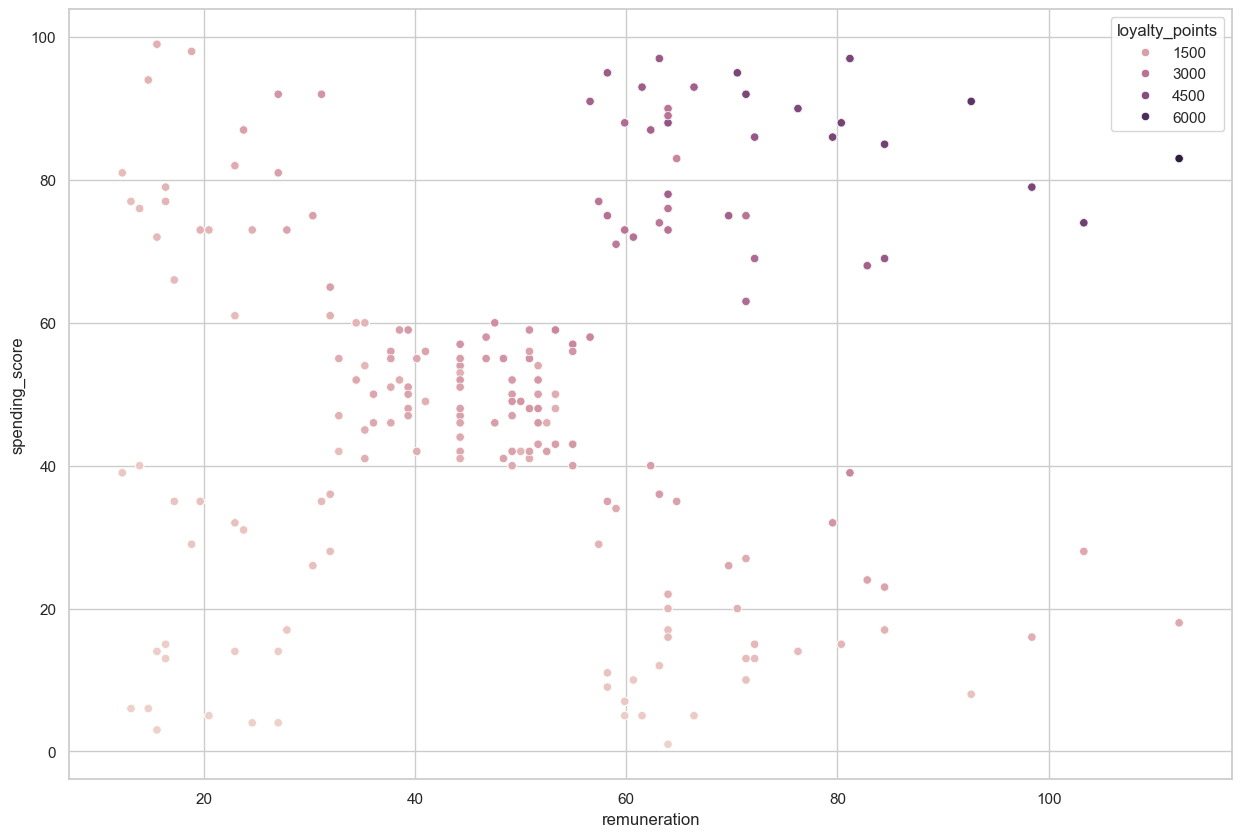

In [207]:
# Create a scatterplot with Seaborn.
sns.scatterplot(data=df3, 
                x='remuneration', 
                y='spending_score', 
                hue='loyalty_points')

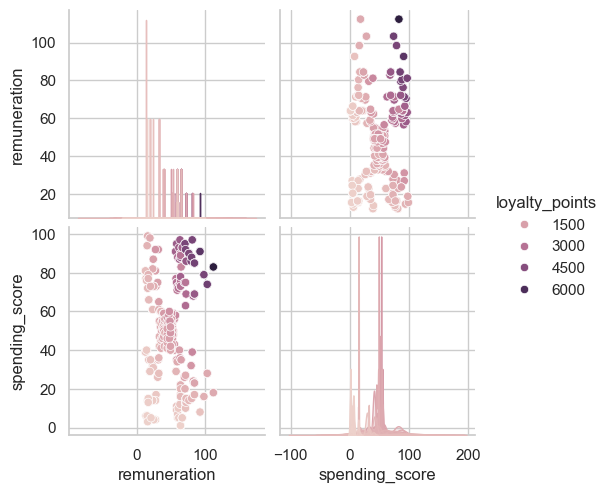

In [208]:
# Create a pairplot with Seaborn.
x = df3[['remuneration', 'spending_score']]

sns.pairplot(df3, 
             vars=x,
             hue='loyalty_points',
             diag_kind='kde')

## 3. Elbow and silhoutte methods

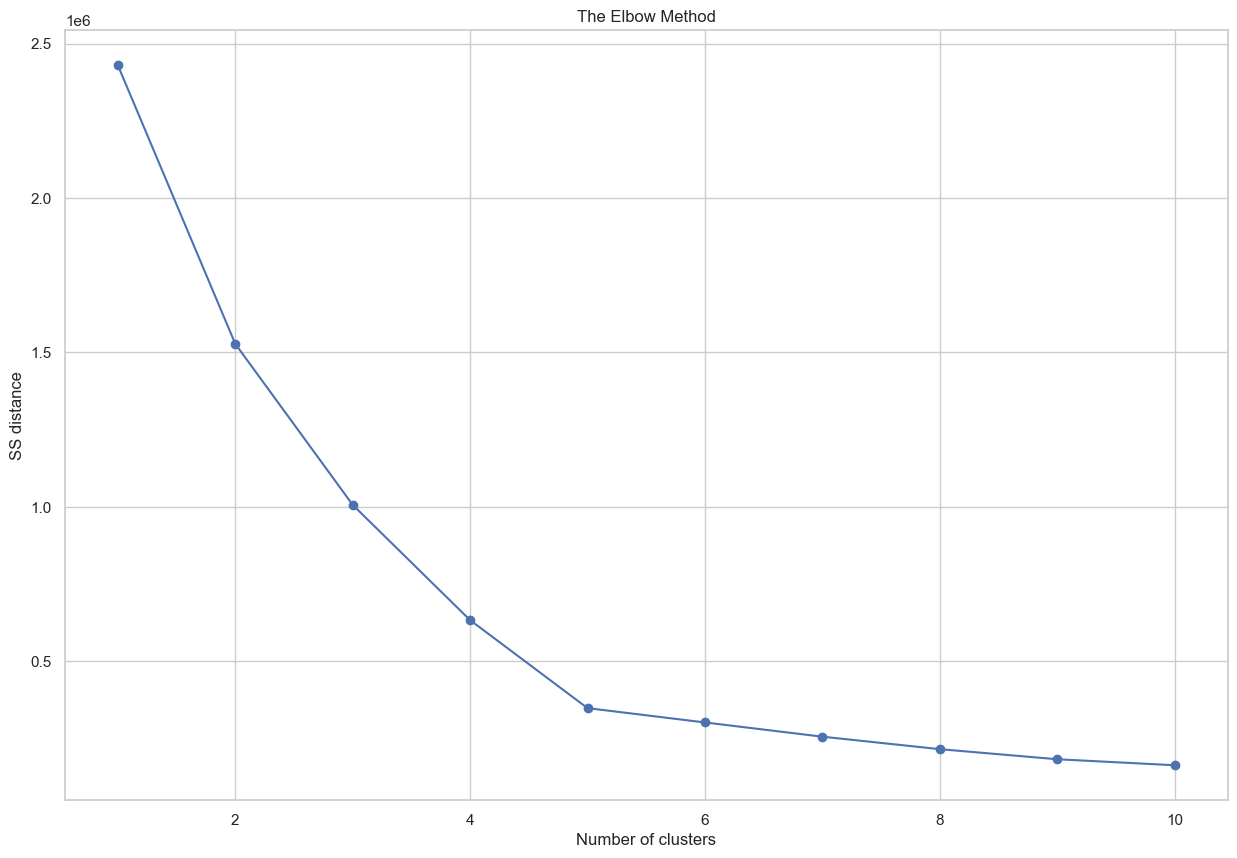

In [209]:
# Determine the number of clusters: Elbow method.
# Import the KMeans class.
from sklearn.cluster import KMeans 

#create empty DF
ss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i,
                    init='k-means++',
                    max_iter=500,
                    n_init=10,
                    random_state=42)
    kmeans.fit(x)
    ss.append(kmeans.inertia_)

# Plot the elbow method.
plt.plot(range(1, 11),
         ss,
         marker='o')

# Insert labels and title.
plt.title("The Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("SS distance")

plt.show()

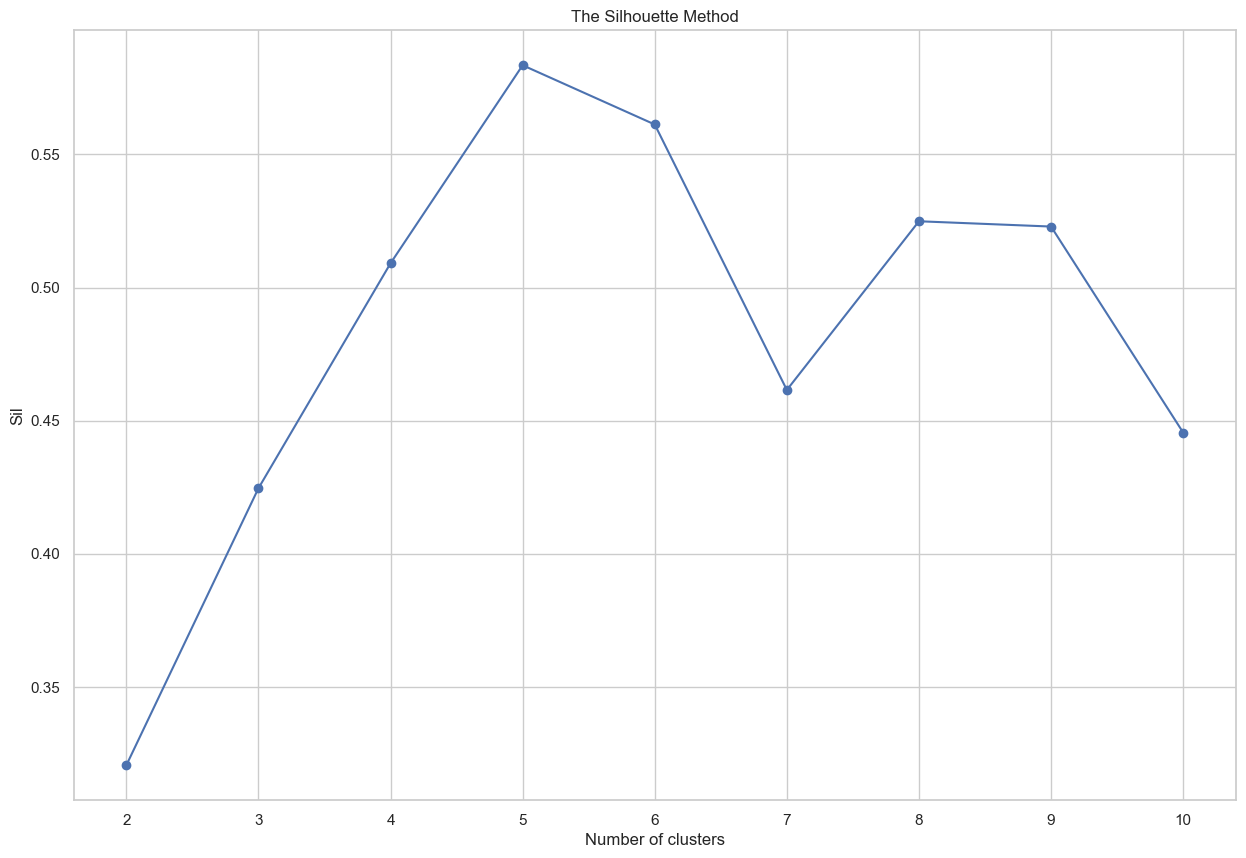

In [210]:
# Determine the number of clusters: Silhouette method.
from sklearn.metrics import silhouette_score

# Find the range of clusters to be used using silhouette method.
sil = []
kmax = 10

for k in range(2, kmax+1):
    kmeans_s = KMeans(n_clusters=k).fit(x)
    labels = kmeans_s.labels_
    sil.append(silhouette_score(x,
                                labels,
                                metric='euclidean'))

# Plot the silhouette method.
plt.plot(range(2, kmax+1),
         sil,
         marker='o')

# Insert labels and title.
plt.title("The Silhouette Method")
plt.xlabel("Number of clusters")
plt.ylabel("Sil")

plt.show()

## 4. Evaluate k-means model at different values of *k*

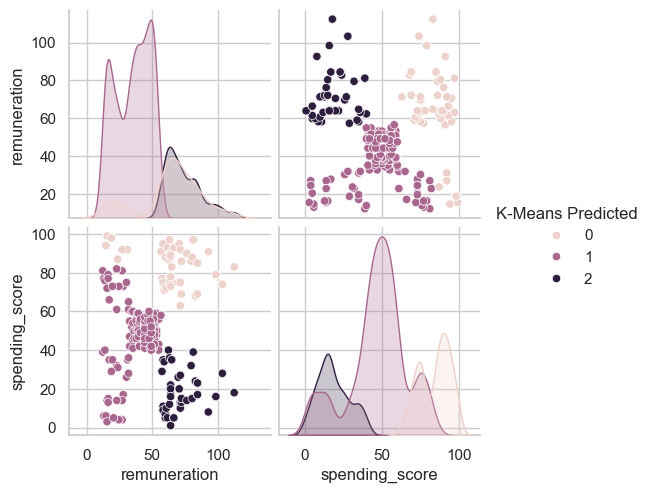

In [211]:
# Use 3 clusters.
kmeans = KMeans(n_clusters = 3, 
                max_iter = 15000,
                init='k-means++',
                random_state=42).fit(x)

clusters = kmeans.labels_

x['K-Means Predicted'] = clusters

# Plot the predicted.
sns.pairplot(x,
             hue='K-Means Predicted',
             diag_kind= 'kde')

In [212]:
# Check the number of observations per predicted class.
x['K-Means Predicted'].value_counts()

K-Means Predicted
1    1220
0     429
2     351
Name: count, dtype: int64

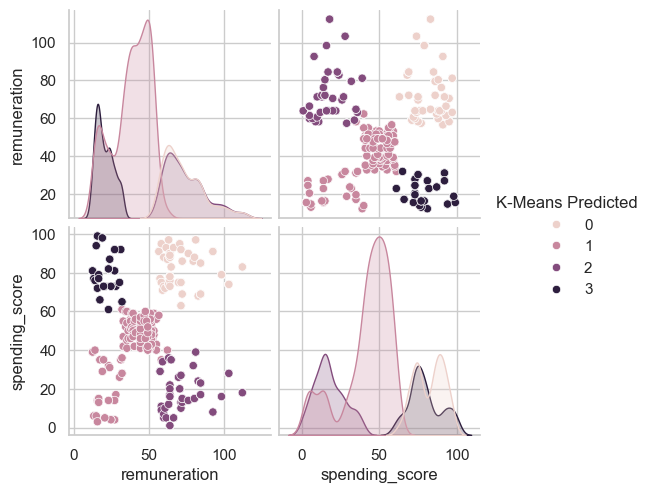

In [213]:
# checking 4 clusters 
kmeans = KMeans(n_clusters = 4, 
                max_iter = 15000,
                init='k-means++',
                random_state=42).fit(x)

clusters = kmeans.labels_

x['K-Means Predicted'] = clusters

# Plot the predicted.
sns.pairplot(x,
             hue='K-Means Predicted',
             diag_kind= 'kde')

In [214]:
x['K-Means Predicted'].value_counts()

K-Means Predicted
1    1038
0     356
2     337
3     269
Name: count, dtype: int64

Text(0.5, 1.02, 'Kmeans Clustering')

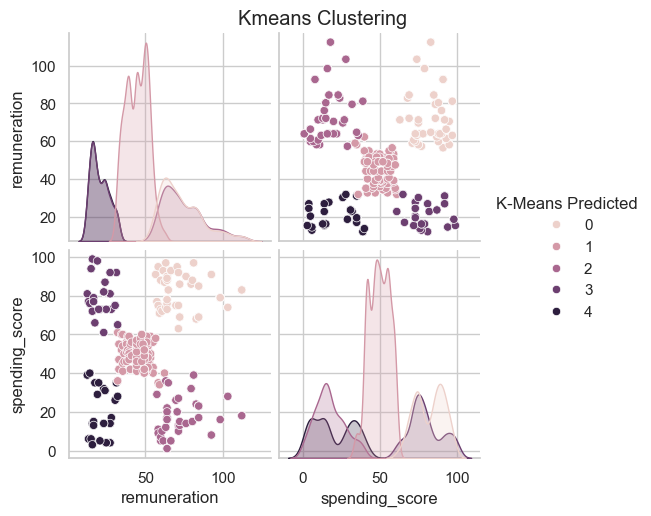

In [215]:
# Use 5 clusters.
kmeans = KMeans(n_clusters = 5, 
                max_iter = 15000,
                init='k-means++',
                random_state=42).fit(x)

clusters = kmeans.labels_

x['K-Means Predicted'] = clusters

# Plot the predicted.
sns.pairplot(x,
             hue='K-Means Predicted',
             diag_kind= 'kde')
plt.suptitle("Kmeans Clustering", y=1.02)


In [216]:
x['K-Means Predicted'].value_counts()

K-Means Predicted
1    774
0    356
2    330
4    271
3    269
Name: count, dtype: int64

## Findings
5 clusters is the most fitting number here. 
- Elbow plot: Elbow plot showed a clear reduction of inertia 5. This measures how well each point fits into its own cluster versus others.
- while the silhouette method peaks at 4 and 8, our pairplot showed that only 4 clusters results in a very spread out group 1. 5 clusters captures the lower remuneration/ lower spending score much more precisely
- we see clear, tight and distinct groups when using 5 clusters for renumeration vs spending score.

Cluster groups are:
- low renumeration + low spending score
- median remuneration + median spending score
- low remuneration + high spending score
- high remuneration + low spending score
- high remuneration + high spending score

The majority of people (774) fall into this median remuneration + median spending score range whilst the rest are relatively evenly distributed... smallest group is 269 versus 356 highest

# 

## 1. Load and explore the data

In [217]:
# Import all the necessary packages.
import pandas as pd
import numpy as np
import nltk 
import os 
import matplotlib.pyplot as plt

# nltk.download ('punkt').
# nltk.download ('stopwords').

from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk.corpus import stopwords
from textblob import TextBlob
from scipy.stats import norm

# Import Counter.
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

In [218]:
# Load the data set as df3.
df3

,gender,age,remuneration,spending_score,loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap
...,...,...,...,...,...,...,...,...,...
1995,Female,37,84.46,69,4031,PhD,977,The perfect word game for mixed ages (with Mom...,The perfect word game for mixed ages (with Mom
1996,Female,43,92.66,8,539,PhD,979,Great game. Did not think I would like it whe...,Super fun
1997,Male,34,92.66,91,5614,graduate,1012,Great game for all.........\nKeeps the mind ni...,Great Game
1998,Male,34,98.40,16,1048,PhD,1031,fun game!,Four Stars


In [219]:
# Keep necessary columns. Drop unnecessary columns.
df4 = df3[['review', 'summary', 'product']]

# View DataFrame.
df4.head()

,review,summary,product
0,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...,453
1,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...,466
2,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless",254
3,Amazing buy! Bought it as a gift for our new d...,Five Stars,263
4,As my review of GF9's previous screens these w...,Money trap,291


In [220]:
# Determine if there are any missing values.
df4.isnull().sum()

review     0
summary    0
product    0
dtype: int64

## 2. Prepare the data for NLP
### 2a) Change to lower case and join the elements in each of the columns respectively (review and summary)

In [221]:
# Review: Change all to lower case and join with a space.
df4['review'] = df4['review'].apply(lambda x: " ".join(word.lower() for word in str(x).split()))
df4['summary'] = df4['summary'].apply(lambda x: " ".join(word.lower() for word in str(x).split()))

# Preview the result.
df4

,review,summary,product
0,"when it comes to a dm's screen, the space on t...",the fact that 50% of this space is wasted on a...,453
1,an open letter to galeforce9*: your unpainted ...,another worthless dungeon master's screen from...,466
2,"nice art, nice printing. why two panels are fi...","pretty, but also pretty useless",254
3,amazing buy! bought it as a gift for our new d...,five stars,263
4,as my review of gf9's previous screens these w...,money trap,291
...,...,...,...
1995,the perfect word game for mixed ages (with mom...,the perfect word game for mixed ages (with mom,977
1996,great game. did not think i would like it when...,super fun,979
1997,great game for all......... keeps the mind nim...,great game,1012
1998,fun game!,four stars,1031


### 2b) Replace punctuation in each of the columns respectively (review and summary)

In [222]:
# Replace all the punctuations in review column.

# Summary: Change all to lower case and join with a space.
df4['review'] = df4['review'].str.replace(r'[^a-z\s]', '', regex=True)
df4['summary'] = df4['summary'].str.replace(r'[^a-z\s]', '', regex=True)

# view
df4

,review,summary,product
0,when it comes to a dms screen the space on the...,the fact that of this space is wasted on art ...,453
1,an open letter to galeforce your unpainted min...,another worthless dungeon masters screen from ...,466
2,nice art nice printing why two panels are fill...,pretty but also pretty useless,254
3,amazing buy bought it as a gift for our new dm...,five stars,263
4,as my review of gfs previous screens these wer...,money trap,291
...,...,...,...
1995,the perfect word game for mixed ages with mom ...,the perfect word game for mixed ages with mom,977
1996,great game did not think i would like it when ...,super fun,979
1997,great game for all keeps the mind nimble,great game,1012
1998,fun game,four stars,1031


In [223]:
df4.review.duplicated().sum()

np.int64(50)

In [224]:
df4.summary.duplicated().sum()

np.int64(649)

### 2c) Drop duplicates in both columns

In [225]:
# Drop duplicates in both columns.
df4 = df4.drop_duplicates(subset=['review', 'summary'])
# View DataFrame.
df4

,review,summary,product
0,when it comes to a dms screen the space on the...,the fact that of this space is wasted on art ...,453
1,an open letter to galeforce your unpainted min...,another worthless dungeon masters screen from ...,466
2,nice art nice printing why two panels are fill...,pretty but also pretty useless,254
3,amazing buy bought it as a gift for our new dm...,five stars,263
4,as my review of gfs previous screens these wer...,money trap,291
...,...,...,...
1995,the perfect word game for mixed ages with mom ...,the perfect word game for mixed ages with mom,977
1996,great game did not think i would like it when ...,super fun,979
1997,great game for all keeps the mind nimble,great game,1012
1998,fun game,four stars,1031


## 3. Tokenise and create wordclouds

In [226]:
# Create new DataFrame (copy DataFrame).
df5 = df4.copy()

# View DataFrame.
df5

,review,summary,product
0,when it comes to a dms screen the space on the...,the fact that of this space is wasted on art ...,453
1,an open letter to galeforce your unpainted min...,another worthless dungeon masters screen from ...,466
2,nice art nice printing why two panels are fill...,pretty but also pretty useless,254
3,amazing buy bought it as a gift for our new dm...,five stars,263
4,as my review of gfs previous screens these wer...,money trap,291
...,...,...,...
1995,the perfect word game for mixed ages with mom ...,the perfect word game for mixed ages with mom,977
1996,great game did not think i would like it when ...,super fun,979
1997,great game for all keeps the mind nimble,great game,1012
1998,fun game,four stars,1031


In [227]:
# tokenize
df5['tokens'] = df5['review'].apply(word_tokenize)
df5['tokens_sum'] = df5['summary'].apply(word_tokenize)

# Preview data.
df5.head()

,review,summary,product,tokens,tokens_sum
0,when it comes to a dms screen the space on the...,the fact that of this space is wasted on art ...,453,"[when, it, comes, to, a, dms, screen, the, spa...","[the, fact, that, of, this, space, is, wasted,..."
1,an open letter to galeforce your unpainted min...,another worthless dungeon masters screen from ...,466,"[an, open, letter, to, galeforce, your, unpain...","[another, worthless, dungeon, masters, screen,..."
2,nice art nice printing why two panels are fill...,pretty but also pretty useless,254,"[nice, art, nice, printing, why, two, panels, ...","[pretty, but, also, pretty, useless]"
3,amazing buy bought it as a gift for our new dm...,five stars,263,"[amazing, buy, bought, it, as, a, gift, for, o...","[five, stars]"
4,as my review of gfs previous screens these wer...,money trap,291,"[as, my, review, of, gfs, previous, screens, t...","[money, trap]"


In [228]:
all_tokens_review = [token for sublist in df5['tokens'] for token in sublist]
all_tokens_summary = [token for sublist in df5['tokens_sum'] for token in sublist]

# Import the FreqDist class.
from nltk.probability import FreqDist

# Calculate the frequency distribution.
fdist_rev = FreqDist(all_tokens_review)
fdist_sum = FreqDist(all_tokens_summary)

# Preview data.
print(fdist_rev)
print(fdist_sum)

<FreqDist with 7304 samples and 111080 outcomes>
<FreqDist with 1523 samples and 9228 outcomes>


In [229]:
# Filter out tokens that are neither alphabets nor numbers (to eliminate punctuation marks, etc.).
tokens_rev = [word for word in all_tokens_review if word.isalnum()]
tokens_sum = [word for word in all_tokens_summary if word.isalnum()]

# Download the stopword list.
nltk.download ('stopwords')
from nltk.corpus import stopwords

# Create a set of English stopwords.
english_stopwords = set(stopwords.words('english'))

# Create a filtered list of tokens without stopwords.
tokens_rev2 = [x for x in tokens_rev if x.lower() not in english_stopwords]
tokens_sum2 = [x for x in tokens_sum if x.lower() not in english_stopwords]

# Define an empty string variable.
tokens_rev2_string = ''
tokens_sum2_string = ''

for value in tokens_rev:
    # Add each filtered token word to the string.
    tokens_rev2_string = tokens_rev2_string + value + ' '

for value in tokens_sum:
    # Add each filtered token word to the string.
    tokens_sum2_string = tokens_sum2_string + value + ' '
    

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/annievert/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


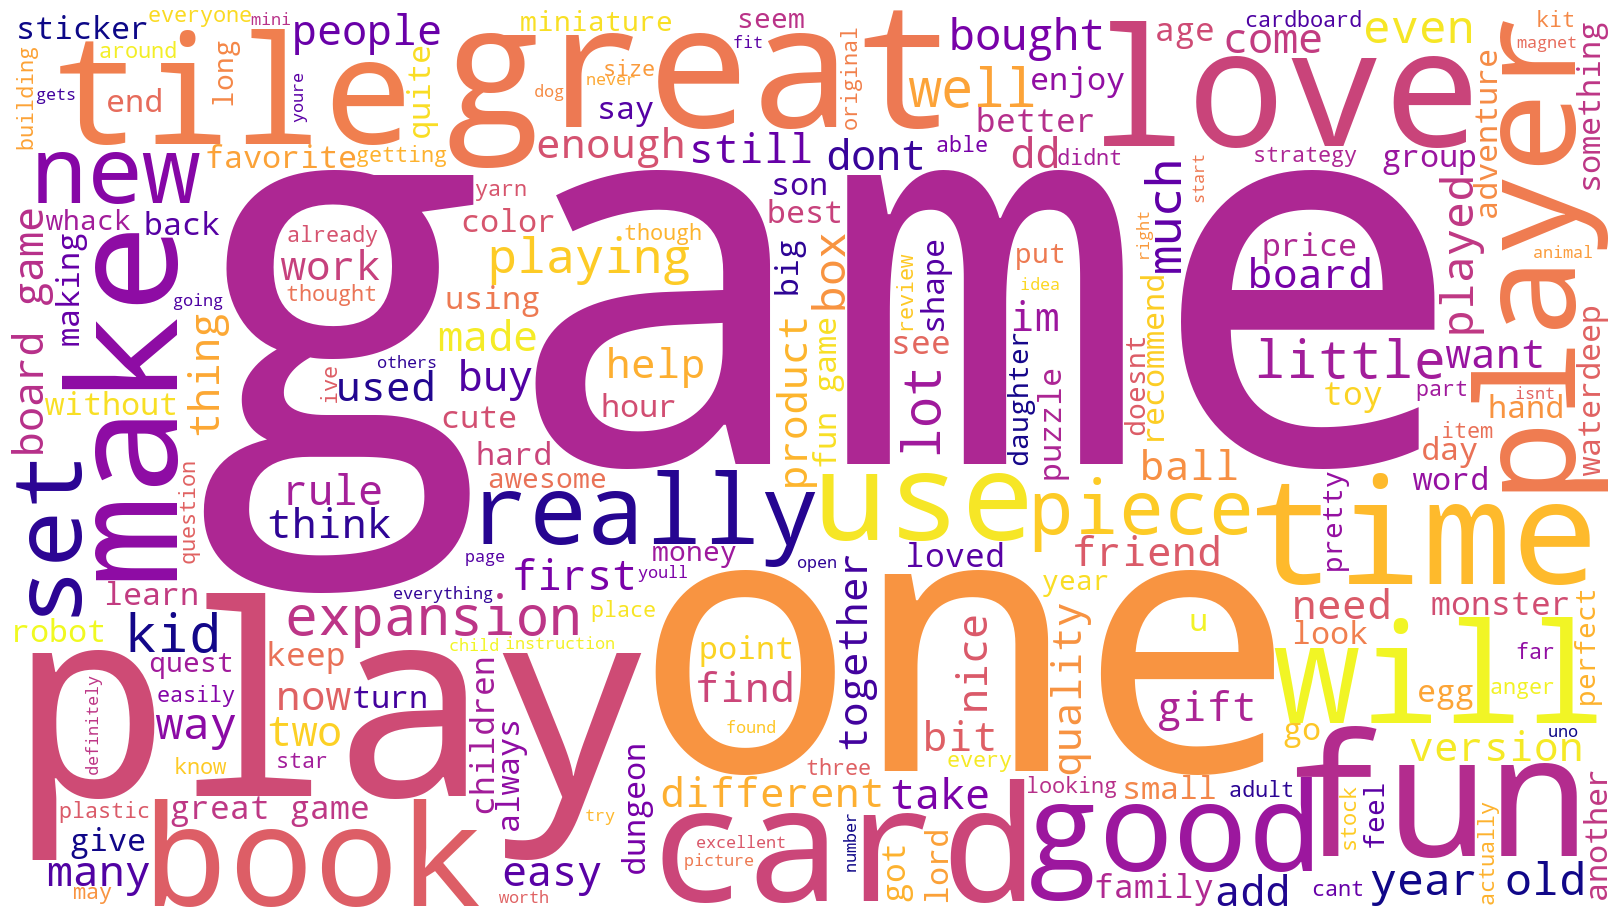

In [230]:
# Review: Plot the WordCloud image for reviews.
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Create a WordCloud.
wordcloud = WordCloud(width = 1600, height = 900, 
                background_color ='white', 
                colormap='plasma', 
                min_font_size = 10).generate(tokens_rev2_string) 

# Plot the WordCloud image.                        
plt.figure(figsize = (16, 9), facecolor = None) 
plt.imshow(wordcloud) 
plt.axis('off') 
plt.tight_layout(pad = 0) 
plt.show()


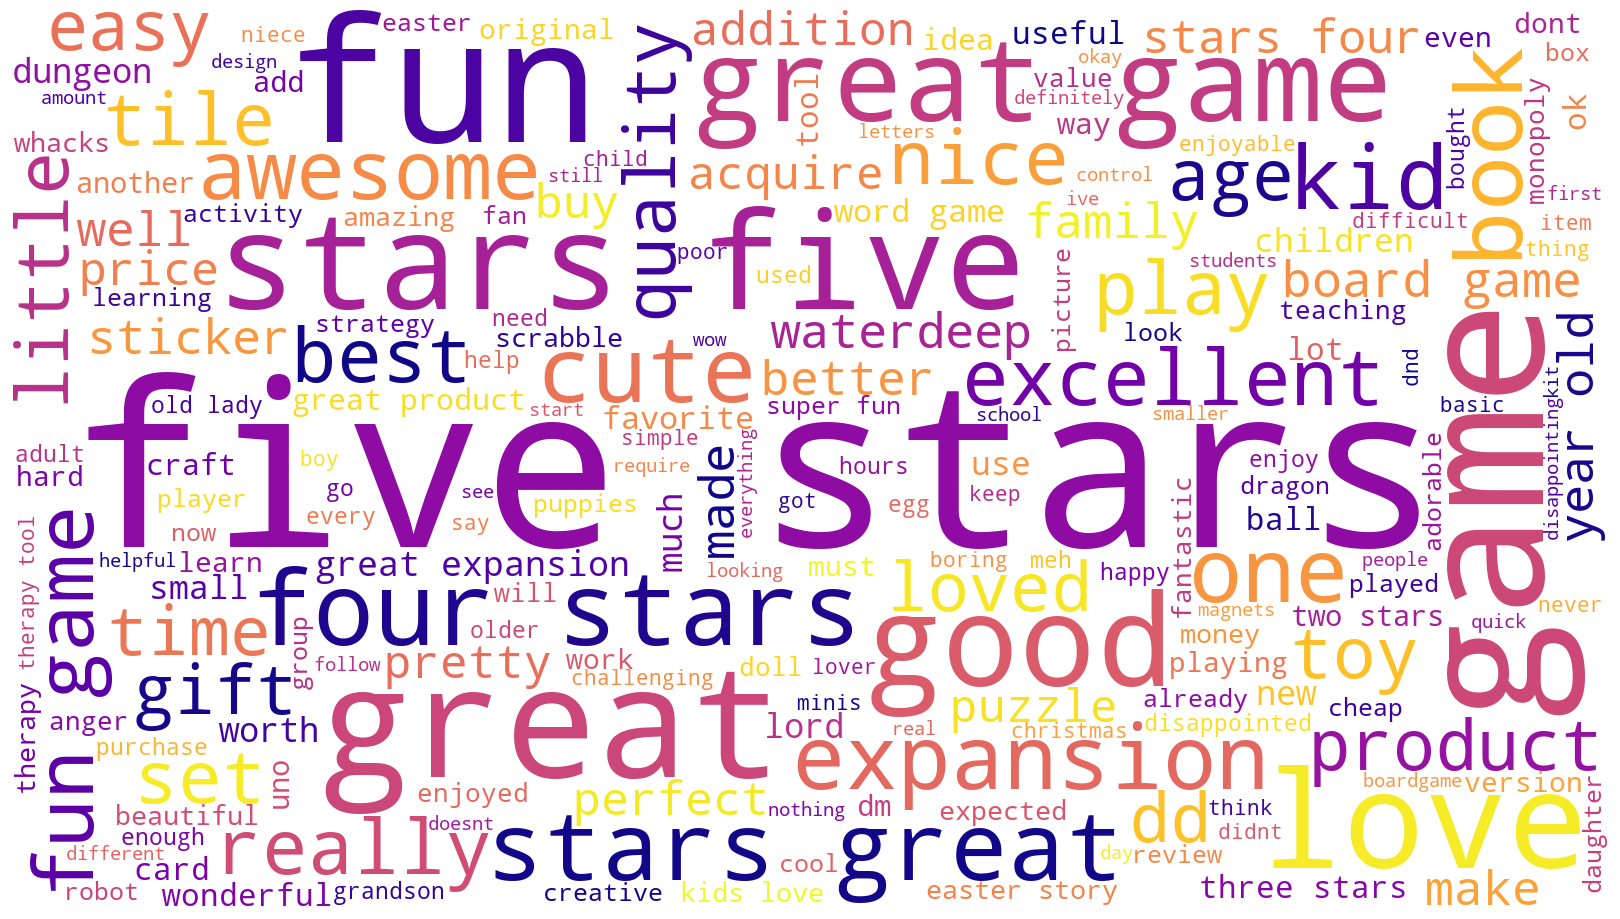

In [231]:
# Plot the WordCloud image for summary.

# Create a WordCloud.
wordcloud = WordCloud(width = 1600, height = 900, 
                background_color ='white', 
                colormap='plasma', 
                min_font_size = 10).generate(tokens_sum2_string) 

# Plot the WordCloud image.                        
plt.figure(figsize = (16, 9), facecolor = None) 
plt.imshow(wordcloud) 
plt.axis('off') 
plt.tight_layout(pad = 0) 
plt.show()

### 4d) Identify 15 most common words and polarity

In [232]:
# Determine the 15 most common words in reviews .
fdist_rev = FreqDist(tokens_rev2)

# Preview the data.
fdist_rev

FreqDist({'game': 1671, 'great': 580, 'fun': 552, 'one': 530, 'play': 502, 'like': 414, 'love': 323, 'really': 319, 'get': 319, 'cards': 301, ...})

In [233]:
# Determine the 15 most common words in summary .
fdist_sum = FreqDist(tokens_sum2)

# Preview the data.
fdist_sum

FreqDist({'stars': 427, 'five': 342, 'game': 319, 'great': 295, 'fun': 218, 'love': 93, 'good': 92, 'four': 58, 'like': 54, 'expansion': 52, ...})

## 5. Review polarity and sentiment: Plot histograms of polarity (use 15 bins) and sentiment scores for the respective columns.

In [234]:
# Provided function.
def generate_polarity(comment):
    '''Extract polarity score (-1 to +1) for each comment'''
    return TextBlob(comment).sentiment[0]

In [235]:
# Determine polarity of both columns. 
df5['polarity_rev'] = df5['review'].apply(generate_polarity)
df5['polarity_sum'] = df5['summary'].apply(generate_polarity)


# View output.
df5

,review,summary,product,tokens,tokens_sum,polarity_rev,polarity_sum
0,when it comes to a dms screen the space on the...,the fact that of this space is wasted on art ...,453,"[when, it, comes, to, a, dms, screen, the, spa...","[the, fact, that, of, this, space, is, wasted,...",-0.036111,0.150000
1,an open letter to galeforce your unpainted min...,another worthless dungeon masters screen from ...,466,"[an, open, letter, to, galeforce, your, unpain...","[another, worthless, dungeon, masters, screen,...",0.035952,-0.800000
2,nice art nice printing why two panels are fill...,pretty but also pretty useless,254,"[nice, art, nice, printing, why, two, panels, ...","[pretty, but, also, pretty, useless]",0.116640,0.000000
3,amazing buy bought it as a gift for our new dm...,five stars,263,"[amazing, buy, bought, it, as, a, gift, for, o...","[five, stars]",0.578788,0.000000
4,as my review of gfs previous screens these wer...,money trap,291,"[as, my, review, of, gfs, previous, screens, t...","[money, trap]",-0.316667,0.000000
...,...,...,...,...,...,...,...
1995,the perfect word game for mixed ages with mom ...,the perfect word game for mixed ages with mom,977,"[the, perfect, word, game, for, mixed, ages, w...","[the, perfect, word, game, for, mixed, ages, w...",0.168750,0.200000
1996,great game did not think i would like it when ...,super fun,979,"[great, game, did, not, think, i, would, like,...","[super, fun]",0.158333,0.316667
1997,great game for all keeps the mind nimble,great game,1012,"[great, game, for, all, keeps, the, mind, nimble]","[great, game]",0.200000,0.200000
1998,fun game,four stars,1031,"[fun, game]","[four, stars]",-0.050000,0.000000


In [236]:
# Determine subjectivity of both columns. 
# def function to exctract a subjectivity score for the comment. 
def generate_subjectivity(comment):
    return TextBlob(comment).sentiment[1]
    
df5['subjectivity_rev'] = df5['review'].apply(generate_subjectivity)
df5['subjectivity_sum'] = df5['summary'].apply(generate_subjectivity)

# View output.
df5

,review,summary,product,tokens,tokens_sum,polarity_rev,polarity_sum,subjectivity_rev,subjectivity_sum
0,when it comes to a dms screen the space on the...,the fact that of this space is wasted on art ...,453,"[when, it, comes, to, a, dms, screen, the, spa...","[the, fact, that, of, this, space, is, wasted,...",-0.036111,0.150000,0.486111,0.500000
1,an open letter to galeforce your unpainted min...,another worthless dungeon masters screen from ...,466,"[an, open, letter, to, galeforce, your, unpain...","[another, worthless, dungeon, masters, screen,...",0.035952,-0.800000,0.442976,0.900000
2,nice art nice printing why two panels are fill...,pretty but also pretty useless,254,"[nice, art, nice, printing, why, two, panels, ...","[pretty, but, also, pretty, useless]",0.116640,0.000000,0.430435,0.733333
3,amazing buy bought it as a gift for our new dm...,five stars,263,"[amazing, buy, bought, it, as, a, gift, for, o...","[five, stars]",0.578788,0.000000,0.784848,0.000000
4,as my review of gfs previous screens these wer...,money trap,291,"[as, my, review, of, gfs, previous, screens, t...","[money, trap]",-0.316667,0.000000,0.316667,0.000000
...,...,...,...,...,...,...,...,...,...
1995,the perfect word game for mixed ages with mom ...,the perfect word game for mixed ages with mom,977,"[the, perfect, word, game, for, mixed, ages, w...","[the, perfect, word, game, for, mixed, ages, w...",0.168750,0.200000,0.491667,0.550000
1996,great game did not think i would like it when ...,super fun,979,"[great, game, did, not, think, i, would, like,...","[super, fun]",0.158333,0.316667,0.310043,0.433333
1997,great game for all keeps the mind nimble,great game,1012,"[great, game, for, all, keeps, the, mind, nimble]","[great, game]",0.200000,0.200000,0.575000,0.575000
1998,fun game,four stars,1031,"[fun, game]","[four, stars]",-0.050000,0.000000,0.300000,0.000000


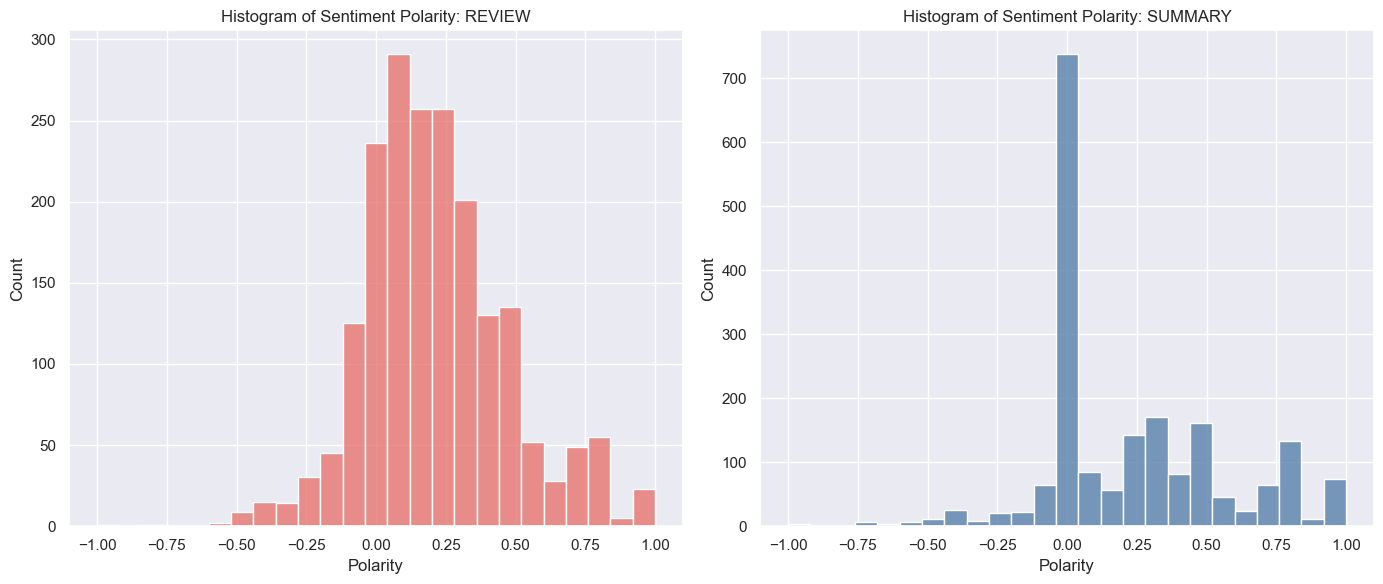

In [237]:
# Set theme
sns.set_theme(style="darkgrid")

# Create dual plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot first histogram (Reviews) on the first axis
sns.histplot(df5['polarity_rev'], bins=25, color='#e66d66', ax=axes[0])
axes[0].set_title('Histogram of Sentiment Polarity: REVIEW')
axes[0].set_xlabel('Polarity')

# Plot the second histogram (Summaries) on the second axis
sns.histplot(df5['polarity_sum'], bins=25, color='#4e79a7', ax=axes[1])
axes[1].set_title('Histogram of Sentiment Polarity: SUMMARY')
axes[1].set_xlabel('Polarity')

# adjust spacing so titles don't overlap
plt.tight_layout()

plt.show()

## 6. Identify top 20 positive and negative reviews and summaries respectively

In [238]:
# Top 20 positive reviews.
positive_sentiment_review = df5.nlargest(10, 'polarity_rev')
positive_sentiment_review = positive_sentiment_review[['review', 'polarity_rev', 'subjectivity_rev']]

# adjust column width 
positive_sentiment_review.style.set_properties(subset=['review'], **{'width': '1200px'})

# View output.
positive_sentiment_review

,review,polarity_rev,subjectivity_rev
7,came in perfect condition,1.0,1.0
165,awesome book,1.0,1.0
194,awesome gift,1.0,1.0
496,excellent activity for teaching selfmanagement...,1.0,1.0
524,perfect just what i ordered,1.0,1.0
591,wonderful product,1.0,1.0
609,delightful product,1.0,1.0
621,wonderful for my grandson to learn the resurre...,1.0,1.0
790,perfect,1.0,1.0
933,awesome,1.0,1.0


In [239]:
# Top 20 positive summaries.
positive_sentiment_summary = df5.nlargest(10, 'polarity_sum')
positive_sentiment_summary = positive_sentiment_summary[['summary', 'polarity_sum', 'subjectivity_sum']]

# adjust column width 
positive_sentiment_summary.style.set_properties(subset=['summary'], **{'width': '1200px'})

# View output.
positive_sentiment_summary

,summary,polarity_sum,subjectivity_sum
6,best gm screen ever,1.0,0.3
28,wonderful designs,1.0,1.0
32,perfect,1.0,1.0
80,theyre the perfect size to keep in the car or ...,1.0,1.0
134,perfect for preschooler,1.0,1.0
140,awesome sticker activity for the price,1.0,1.0
161,awesome book,1.0,1.0
163,he was very happy with his gift,1.0,1.0
187,awesome,1.0,1.0
210,awesome and welldesigned for year olds,1.0,1.0


In [240]:
# Top 20 negative reviews.
negative_sentiment_reviews = df5.nsmallest(10, 'polarity_rev')

# eliminate unnessecary columns 
negative_sentiment_reviews = negative_sentiment_reviews[['review', 'polarity_rev', 'subjectivity_rev']]

# adjust column width 
negative_sentiment_reviews.style.set_properties(subset=['review'], **{'width': '1300px'})

# View output.
negative_sentiment_reviews

,review,polarity_rev,subjectivity_rev
208,booo unles you are patient know how to measure...,-1.000000,1.00
182,incomplete kit very disappointing,-0.780000,0.91
1804,im sorry i just find this product to be boring...,-0.583333,0.75
364,one of my staff will be using this game soon s...,-0.550000,0.30
117,i bought this as a christmas gift for my grand...,-0.500000,0.90
227,this was a gift for my daughter i found it dif...,-0.500000,1.00
230,i found the directions difficult,-0.500000,1.00
290,instructions are complicated to follow,-0.500000,1.00
301,difficult,-0.500000,1.00
1524,expensive for what you get,-0.500000,0.70


In [241]:
# Top 20 negative summaries.
negative_sentiment_summaries = df5.nsmallest(10, 'polarity_sum')

# eliminate unnessecary columns 
negative_sentiment_summaries = negative_sentiment_summaries[['summary', 'polarity_sum', 'subjectivity_sum']]

# adjust column width 
negative_sentiment_summaries.style.set_properties(subset=['summary'], **{'width': '1300px'})

# View output.
negative_sentiment_summaries

,summary,polarity_sum,subjectivity_sum
21,the worst value ive ever seen,-1.00,1.00
208,boring unless you are a craft person which i am,-1.00,1.00
829,boring,-1.00,1.00
1166,before this i hated running any rpg campaign d...,-0.90,0.70
1,another worthless dungeon masters screen from ...,-0.80,0.90
144,disappointed,-0.75,0.75
631,disappointed,-0.75,0.75
793,disappointed,-0.75,0.75
1620,disappointed,-0.75,0.75
363,promotes anger instead of teaching calming met...,-0.70,0.20


In [242]:
df5

,review,summary,product,tokens,tokens_sum,polarity_rev,polarity_sum,subjectivity_rev,subjectivity_sum
0,when it comes to a dms screen the space on the...,the fact that of this space is wasted on art ...,453,"[when, it, comes, to, a, dms, screen, the, spa...","[the, fact, that, of, this, space, is, wasted,...",-0.036111,0.150000,0.486111,0.500000
1,an open letter to galeforce your unpainted min...,another worthless dungeon masters screen from ...,466,"[an, open, letter, to, galeforce, your, unpain...","[another, worthless, dungeon, masters, screen,...",0.035952,-0.800000,0.442976,0.900000
2,nice art nice printing why two panels are fill...,pretty but also pretty useless,254,"[nice, art, nice, printing, why, two, panels, ...","[pretty, but, also, pretty, useless]",0.116640,0.000000,0.430435,0.733333
3,amazing buy bought it as a gift for our new dm...,five stars,263,"[amazing, buy, bought, it, as, a, gift, for, o...","[five, stars]",0.578788,0.000000,0.784848,0.000000
4,as my review of gfs previous screens these wer...,money trap,291,"[as, my, review, of, gfs, previous, screens, t...","[money, trap]",-0.316667,0.000000,0.316667,0.000000
...,...,...,...,...,...,...,...,...,...
1995,the perfect word game for mixed ages with mom ...,the perfect word game for mixed ages with mom,977,"[the, perfect, word, game, for, mixed, ages, w...","[the, perfect, word, game, for, mixed, ages, w...",0.168750,0.200000,0.491667,0.550000
1996,great game did not think i would like it when ...,super fun,979,"[great, game, did, not, think, i, would, like,...","[super, fun]",0.158333,0.316667,0.310043,0.433333
1997,great game for all keeps the mind nimble,great game,1012,"[great, game, for, all, keeps, the, mind, nimble]","[great, game]",0.200000,0.200000,0.575000,0.575000
1998,fun game,four stars,1031,"[fun, game]","[four, stars]",-0.050000,0.000000,0.300000,0.000000


In [243]:
nltk.download('stopwords')

# create stopwords
stop_words = set(stopwords.words('english'))
stop_words.update(['game','games','would', 'really', 'much','it', 'i', 'br', 'one', 'get']) 

# Filter the tokens into a single list
tokens2 = [word.lower() for sublist in df5['tokens'] for word in sublist if word.lower() not in stop_words]

# Create the frequency DataFrame from tokens2 
counts = pd.DataFrame(Counter(tokens2).most_common(15), 
                      columns=['Word', 'Frequency']).set_index('Word')

# Sort for the bar chart
counts = counts.sort_values(by='Frequency', ascending=False)

counts

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/annievert/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Frequency
Word,
great,580
fun,552
play,502
like,414
love,323
cards,301
tiles,297
time,291
good,289


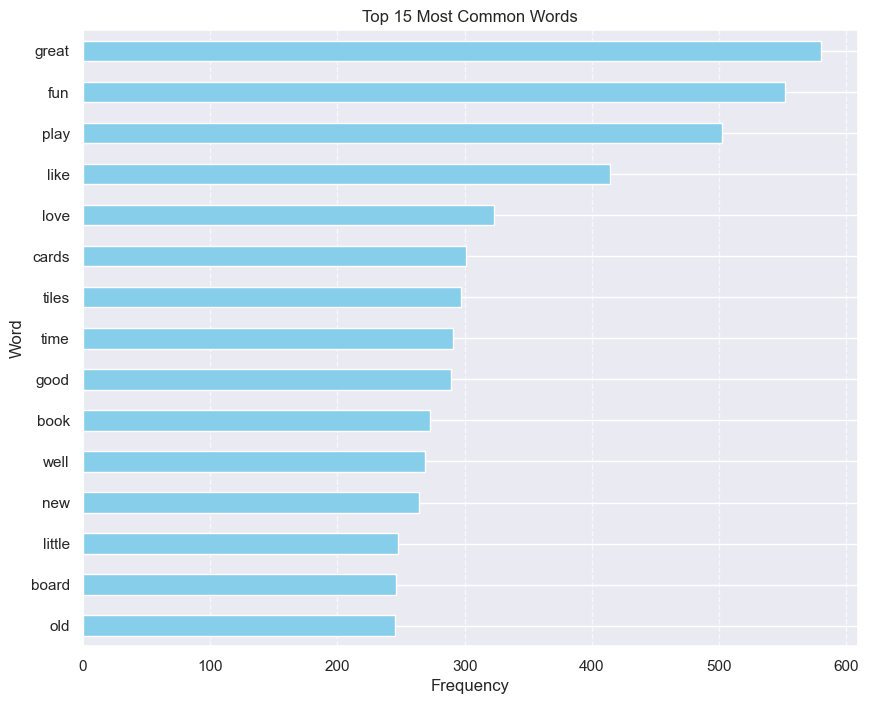

In [244]:
# create barplot and sort with highest values at the top
counts = counts.sort_values(by='Frequency',
                            ascending=True)
# plot thge figure 
counts.plot(kind='barh', figsize=(10, 8), 
            color='skyblue', legend=False)
# add titles 
plt.title('Top 15 Most Common Words')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.grid(axis='x', 
         linestyle='--', 
         alpha=0.7) 
plt.savefig('Top_words.png', dpi=300, bbox_inches='tight')  
plt.show()

In [245]:
# checking product based sentiment scores 
product_sentiment = df5.groupby('product')['polarity_sum'].mean().reset_index()

# Sorting by sentiment (lowest/most negative first)
product_sentiment = product_sentiment.sort_values(by='polarity_sum')

# View the 5 products with the lowest sentiment
print(product_sentiment.head())

     product  polarity_sum
197    11056     -0.030000
46      1501     -0.019375
13       466      0.006250
97      3525      0.008333
177     9507      0.015833


In [246]:
# determining worst products 
# Grouping by product and determining average score
product_averages = df5.groupby('product')[['polarity_sum', 'subjectivity_sum']].mean()

# determine 10 products with the lowest average sentiment
worst_products = product_averages.nsmallest(10, 'polarity_sum').reset_index()

# 3. View the result
print(worst_products)


   product  polarity_sum  subjectivity_sum
0    11056     -0.030000          0.125000
1     1501     -0.019375          0.277292
2      466      0.006250          0.225000
3     3525      0.008333          0.290000
4     9507      0.015833          0.278333
5     4047      0.018333          0.197963
6     3967      0.029545          0.501818
7     2285      0.031250          0.310000
8      123      0.035000          0.208750
9     7143      0.053333          0.293333


In [247]:
# determining best products 
# Grouping by product and determining average score
# Determine 10 products with the lowest average sentiment
best_products = product_averages.nlargest(10, 'polarity_sum')

# View the result
print(best_products)

         polarity_sum  subjectivity_sum
product                                
10995        0.550000          0.561111
3885         0.475833          0.652500
7373         0.475000          0.605000
4415         0.470000          0.510000
1473         0.418000          0.481667
9560         0.414000          0.425000
263          0.411111          0.416667
978          0.403704          0.580093
3878         0.395625          0.562500
979          0.392361          0.414583


In [248]:
# Filter for reviews that are more factual (low subjectivity) and negative (low polarity)
true_complaints = df5[(df5['polarity_sum'] < -0.2) & (df5['subjectivity_sum'] < 0.5)]

# Group by product to see which items have the most complaints
complaint_counts = true_complaints.groupby('product').size().sort_values(ascending=False).reset_index(name='complaint_count')

# view products with the most complaints 
print("Products with the most objective quality issues:")
print(complaint_counts.head(10))

Products with the most objective quality issues:
   product  complaint_count
0    11056                2
1     1307                2
2     1940                2
3     2285                2
4     3629                1
5    11025                1
6     9080                1
7     6507                1
8     6287                1
9     6271                1


In [249]:
# Create a variable sia to store the SentimentIntensityAnalyser() method.
# import the prebuilt rules and values of the vader lexicon.
import os
import nltk
import tempfile

# Create a directory in a location where you definitely have write permissions
# Using the system's temporary directory which should be writable
nltk_data_dir = os.path.join(tempfile.gettempdir(), "my_nltk_data")
os.makedirs(nltk_data_dir, exist_ok=True)

# Set the NLTK data path to your custom directory
nltk.data.path.append(nltk_data_dir)

# Download the vader lexicon to your custom directory
nltk.download('vader_lexicon', download_dir=nltk_data_dir)

[nltk_data] Downloading package vader_lexicon to /var/folders/t6/1tn_4
[nltk_data]     hwj2fb_f_ck0ydr_qh40000gn/T/my_nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [250]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

def get_vader_scores(text):
    if isinstance(text, list):
        text = " ".join(text)
    return sia.polarity_scores(text)

# Apply to the review column
polarity_series = df5['review'].apply(get_vader_scores)

# Convert that series of dictionaries into a df
polarity = pd.DataFrame(list(polarity_series))

# keep the original review text as the index:
polarity.index = df5['review'].apply(lambda x: " ".join(x) if isinstance(x, list) else x)

# view output
polarity

,neg,neu,pos,compound
review,,,,
when it comes to a dms screen the space on the screen itself is at an absolute premium the fact that of this space is wasted on art and not terribly informative or needed art as well makes it completely useless the only reason that i gave it stars and not was that technically speaking it can at least still stand up to block your notes and dice rolls other than that it drops the ball completely,0.107,0.835,0.058,-0.6333
an open letter to galeforce your unpainted miniatures are very not bad your spell cards are great your board games are meh your dm screens however are freaking terrible im still waiting for a single screen that isnt polluted with pointless artwork where useful referenceable tables should be once again youve created a single use screen that is only useful when running the storm kings thunder adventure even despite the fact that its geared to that adventure path its usefulness negligible at best i massive swath of the inner panel is wasted on artwork and a bloated overland map which could have been easily reduced to a single panel in size and the few table you have are nighuseless themselves in short stop making crap dm screens,0.097,0.705,0.198,0.9404
nice art nice printing why two panels are filled with a general forgotten realms map is beyond me most of one of them is all blue ocean such a waste i dont understand why they cant make these dm screens more useful for these kinds of adventures rather than solely the specific adventure youre supposed to be able to transpose this adventure to other lands outside the forgotten realms so even just a list of new monsters or npcs would at least be useful than the map even more would just be stuff related to running the game but broaduse stuff related to giants same thing with curse of strahd why not make it useful for raven loft undead or horror campaigns in general instead a huge amount of screen space is solely mapping out castle ravenloft which is only useful during a small fraction of the time even for the curse of strahd adventure let alone various other ravenloft adventuring they really kill the extended use of these screens by not thinking about their potential use both for the adventure in question as well as use in a broader sense the rage of demons screen is far more useful for broad under dark adventuring covering a lot of rules for the various conditions you may suffer and the map is only one panel this storm giants one is decent for a few tables it includes but really misses the mark maybe they should ask a few dms what they would use,0.143,0.724,0.134,-0.8334
amazing buy bought it as a gift for our new dm and its perfect,0.000,0.514,0.486,0.8860
as my review of gfs previous screens these were completely unnecessary and nearly useless skip them this is the definition of a waste of money,0.196,0.804,0.000,-0.6808
...,...,...,...,...
the perfect word game for mixed ages with mom perhaps giving a little help to the yr old we ages to love it,0.000,0.599,0.401,0.9137
great game did not think i would like it when first received but has turned out to be a lot of fun and we play regularly this order was for an extra set so we can always have it in our travel stuff,0.000,0.767,0.233,0.8968
great game for all keeps the mind nimble,0.000,0.631,0.369,0.6249


In [251]:
# Get the top 5 most positive reviews 
polarity.sort_values('pos', ascending=0).head(10)

,neg,neu,pos,compound
review,,,,
good,0.0,0.0,1.0,0.4404
great,0.0,0.0,1.0,0.6249
fine,0.0,0.0,1.0,0.2023
fantastic,0.0,0.0,1.0,0.5574
great,0.0,0.0,1.0,0.6249
super fun,0.0,0.0,1.0,0.8020
inspiring creativity,0.0,0.0,1.0,0.6597
awesome gift,0.0,0.0,1.0,0.7906
thx,0.0,0.0,1.0,0.3612


In [252]:
# view 10 most negative 
polarity.sort_values('neg', ascending=0).head(10)

,neg,neu,pos,compound
review,,,,
difficult,1.000,0.000,0.000,-0.3612
incomplete kit very disappointing,0.538,0.462,0.000,-0.5413
no more comments,0.524,0.476,0.000,-0.2960
a crappy cardboard ghost of the original hard to believe they did this but they did shame on hasbro disgusting,0.470,0.474,0.056,-0.9052
who doesnt love puppies great instructions pictures fun,0.445,0.334,0.221,-0.5207
not a hard game to learn but not easy to win,0.441,0.489,0.070,-0.7946
i found the directions difficult,0.385,0.615,0.000,-0.3612
different kids had red faces not sure they like,0.368,0.632,0.000,-0.4717
got the product in damaged condition,0.367,0.633,0.000,-0.4404



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


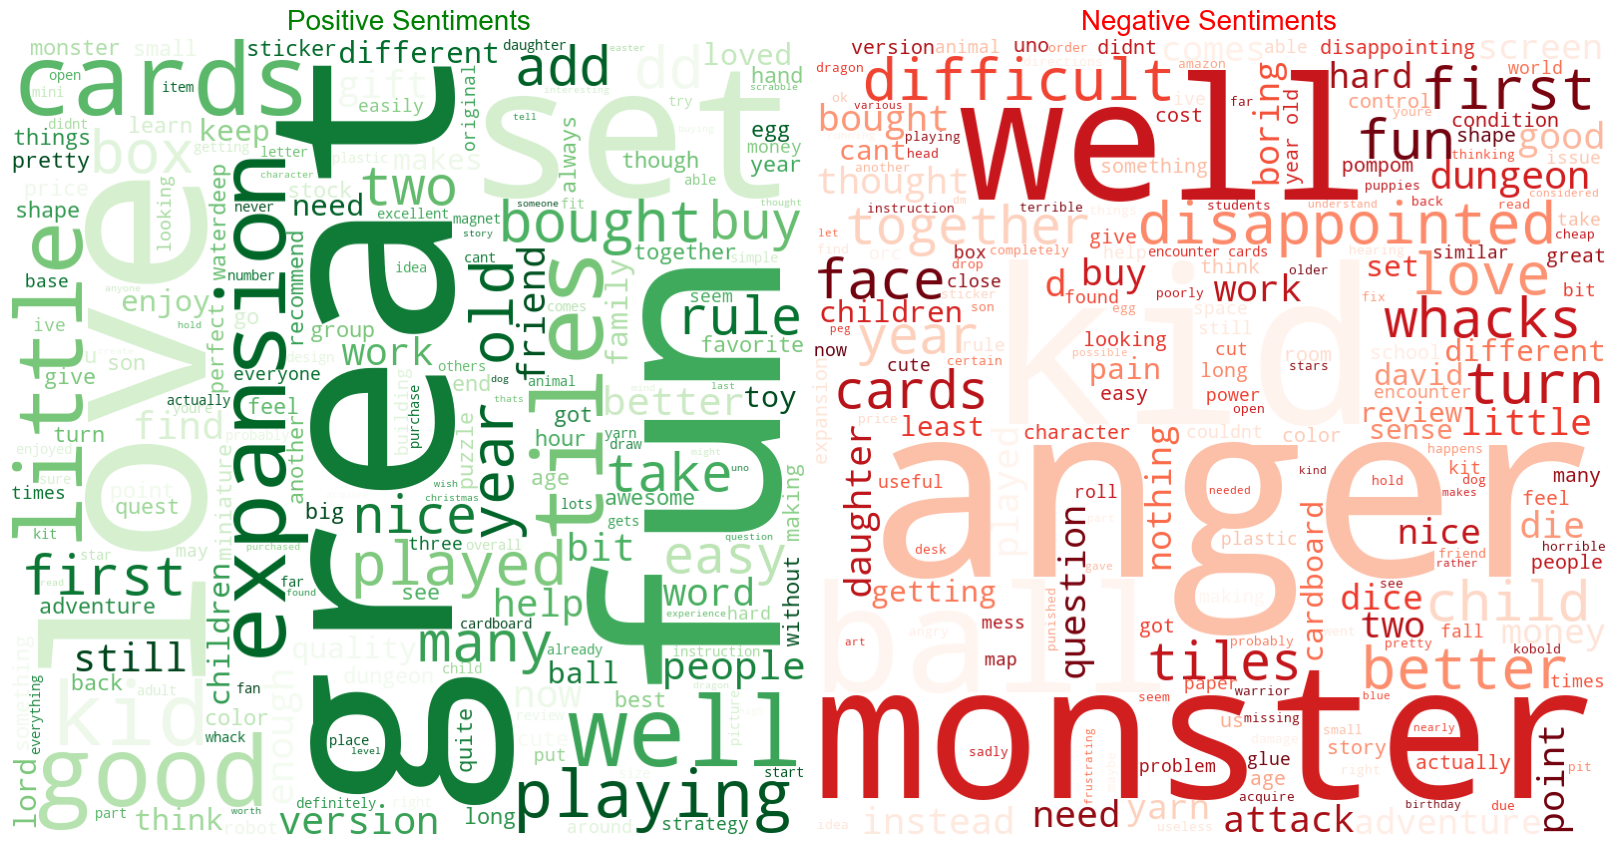

In [253]:
# visualise wordclouds for best and worst products 
!pip install wordcloud
from wordcloud import WordCloud, STOPWORDS

# Setup Stopwords 
comment_words = set(STOPWORDS)
comment_words.update(["game", "pieces", "player", "players", "time", "make", "way","product", 
                      "isnt", "book", "day", "lot", "say", "bit" "instead", "want", "used", 
                      "using", "even","im", "look", "dont", "doesnt", "know", "thing", "youll", 
                      "new", "piece", "card", "tile", "board", "made", "one", "use", "going", 
                      "every", "must", "will", "show", "really", "come", "play", "much", "games"])

# Filter data by sentiment
pos_comments = " ".join(polarity[polarity['compound'] > 0.3].index.astype(str))
neg_comments = " ".join(polarity[polarity['compound'] < -0.3].index.astype(str))

# Positive Cloud
wc_pos = WordCloud(prefer_horizontal=0.99,
                   width=800, height=800, 
                   background_color='white', 
                   stopwords=comment_words, 
                   colormap='Greens', # Green theme for positive
                   min_font_size=10).generate(pos_comments)

# Negative Cloud
wc_neg = WordCloud(prefer_horizontal=0.99,
                   width=800, height=800, 
                   background_color='white', 
                   stopwords=comment_words, 
                   colormap='Reds', # Red theme for negative
                   min_font_size=10).generate(neg_comments)

# Plotting them side-by-side
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Positive plot
ax[0].imshow(wc_pos)
ax[0].set_title('Positive Sentiments', fontsize=20, color='green')
ax[0].axis("off")

# Negative plot
ax[1].imshow(wc_neg)
ax[1].set_title('Negative Sentiments', fontsize=20, color='red')
ax[1].axis("off")

# view
plt.tight_layout(pad=0)
plt.show()

In [254]:
# investigate product based sentiment 

# create new df
polarity_df = pd.DataFrame(list(df5['review'].apply(get_vader_scores)))

# merge with the product column from df5
polarity_new = pd.concat([df5['product'], polarity_df], axis=1)

polarity_new.head()

,product,neg,neu,pos,compound
0,453.0,0.107,0.835,0.058,-0.6333
1,466.0,0.097,0.705,0.198,0.9404
2,254.0,0.143,0.724,0.134,-0.8334
3,263.0,0.000,0.514,0.486,0.8860
4,291.0,0.196,0.804,0.000,-0.6808


In [255]:
# group by product
product_sentiment = polarity_new.groupby('product').mean()

# Sort by the compound score (lowest score = most negative average)
worst_products = product_sentiment.sort_values(by='compound', ascending=True)

worst_products.head(10)

,neg,neu,pos,compound
product,,,,
9080.0,0.113889,0.675333,0.211000,0.281211
263.0,0.091667,0.661333,0.247000,0.283667
1241.0,0.059600,0.679300,0.261200,0.299200
3711.0,0.044875,0.760375,0.194750,0.345650
4452.0,0.043333,0.787333,0.169333,0.353756
3427.0,0.078000,0.722500,0.199400,0.361460
6466.0,0.059300,0.642400,0.298400,0.373180
7573.0,0.021800,0.803200,0.175100,0.375100
6271.0,0.024778,0.805778,0.169333,0.393744


In [256]:
# see both the average sentiment and the number of reviews
stats = polarity_new.groupby('product')['compound'].agg(['mean', 'count'])

# Filter for products with at least 5 reviews, then find the lowest mean
problem_products = stats[stats['count'] >= 5].sort_values(by='mean')

# view data
problem_products.head(10)

,mean,count
product,,
9080.0,0.281211,9
263.0,0.283667,6
1241.0,0.299200,10
3711.0,0.345650,8
4452.0,0.353756,9
3427.0,0.361460,10
6466.0,0.373180,10
7573.0,0.375100,10
6271.0,0.393744,9


In [257]:
# determine best products 
best_products = product_sentiment.sort_values(by='compound', ascending=False)

# view data 
best_products.head(10)

,neg,neu,pos,compound
product,,,,
3955.0,0.012700,0.728000,0.259300,0.926620
3153.0,0.037667,0.738333,0.223889,0.889011
399.0,0.013900,0.653400,0.332900,0.879850
2286.0,0.022000,0.618000,0.360000,0.875690
1940.0,0.027400,0.615600,0.357000,0.873180
3865.0,0.024400,0.702900,0.272700,0.865140
5453.0,0.004000,0.615800,0.380300,0.858030
1459.0,0.015375,0.694375,0.290250,0.845888
3967.0,0.030900,0.712300,0.256900,0.844570


In [258]:
# see both the average sentiment and the number of reviews
stats_best = polarity_new.groupby('product')['compound'].agg(['mean', 'count'])

# Filter for products with at least 5 reviews, then find the highest mean
good_products = stats[stats['count'] >= 5].sort_values(by='mean', ascending=False)

# view data
good_products.head(10)

,mean,count
product,,
3955.0,0.926620,10
3153.0,0.889011,9
399.0,0.879850,10
2286.0,0.875690,10
1940.0,0.873180,10
3865.0,0.865140,10
5453.0,0.858030,10
1459.0,0.845888,8
3967.0,0.844570,10


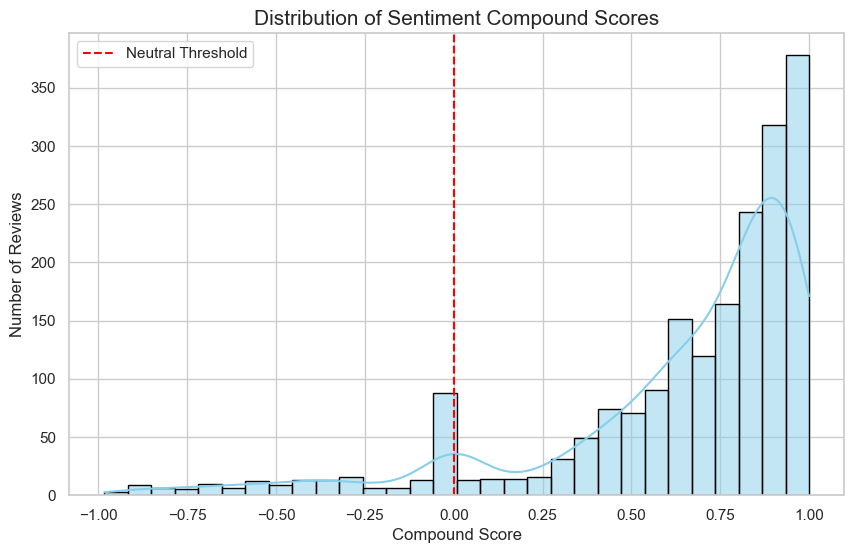

In [259]:
# plot distribution of compound scores 

# Setting theme
sns.set_theme(style="whitegrid")

# Create histogram
plt.figure(figsize=(10, 6))
sns.histplot(polarity_df['compound'], bins=30, kde=True, color='skyblue', edgecolor='black')

# Add titles and labels
plt.title('Distribution of Sentiment Compound Scores', fontsize=15)
plt.xlabel('Compound Score', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)

# Add a neutral score line
plt.axvline(x=0, color='red', linestyle='--', label='Neutral Threshold')
plt.legend()

plt.show()

## Findings
Overall sentiment for turtle games reviews is very positive. based on our product based analysis there may be some specific products that have a more negative sentiment skew, but our histogram of compound scores shows very strong positive review data

the top 10 worst products should undergo product review, and markeeting should shy away from promoting these products. The 10 best products should be investigated and focused on for marketing. My focusing on products with overall high customer satisfaction, ideally this will positively impact sales.

# 